In [1]:
!pwd

/home/ali_work/BenchmarkV3/Towards-Efficient-AutoML-for-Data-Streams-A-Benchmarking-Study


In [1]:
import matplotlib.pyplot as plt 
import json
from glob import glob

from collections import defaultdict
import os
import numpy as np

import pandas as pd


dataset_names=[	    
        'adult',
	    'electricity',
	    'forest_cover',
	    'hyperplane_high_gradual_drift',
	    'insects',
	    'movingRBF',
	    'moving_squares',
	    'new_airlines',
	    'sea_high_abrupt_drift',
	    'sea_high_mixed_drift',
	    'shuttle',
	    'synth_RandomRBFDrift',
	    'synth_agrawal',
	    'vehicle_sensIT',
        'rialto',
        'weather',
        'river_Waveform_2',
        'river_anomalysine',
        'river_Waveform',
        'skmul_aggrawal',
        'skmul_anomalysine_2',
        'river_hyperlane_2',
        'skmul_anomalysine',
        'river_hyperlane',
        'skmul_hyperlane',
        'river_led',
        'skmul_ledgenerator',
        'river_led_default_drift',
        'skmul_ledgenerator_default_drift',
        'river_mixed',
        'skmul_randomRBF_default_drift',
        'river_SEA_2',
        'skmul_randomRBF_gradual',
        'skmul_randomTree_2',
        'river_randomRBF_2',
        'skmul_randomTree',
        'river_randomRBF',
        'river_randomRBF_drift',
        'skmul_SEA_2',
        'river_randomTree_2',
        'skmul_SEA',
        'river_randomTree',
        'skmul_Sine',
        'river_SEA',
        'skmul_STAGGER_2',
        'river_SINE',
        'skmul_STAGGER',
        'river_STAGGER',
        'skmul_Waveform',
        'river_aggrawal'

]


model_names=('HATC','ARFC','AutoClass','AutoStreamML','SRPC', 'EvoAutoML','OnlineAutoML','ChaCha')


dataset_by_model={}
for dataset in dataset_names:
    dataset_by_model[dataset]={}

for model in model_names:
    for dataset in dataset_names:
        dataset_by_model[dataset][model]=glob(f'./experiment-results/{model}/{model}_{dataset}*')

In [2]:
!free -m

               total        used        free      shared  buff/cache   available
Mem:           15435        5164        2913         683        8649       10270
Swap:           8191           0        8191


In [3]:
import gc
import warnings
warnings.filterwarnings('ignore')
gc.collect()

0

In [4]:
import matplotlib.pyplot as plt

print("Default font size:", plt.rcParams["font.size"])  # 10 by default
print("Default axis labels size:", plt.rcParams["axes.labelsize"])  # 12
print("Default title size:", plt.rcParams["axes.titlesize"])  # 14
print("Default xticks/yticks size:", plt.rcParams["xtick.labelsize"])  # 10
print("Default legend size:", plt.rcParams["legend.fontsize"])  # 10


Default font size: 10.0
Default axis labels size: medium
Default title size: large
Default xticks/yticks size: medium
Default legend size: medium


In [5]:
# import seaborn as sns
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
import re
from collections import defaultdict
import gc

def downsample(data, window_size):
    """Averages every `window_size` instances."""
    n = len(data) // window_size * window_size  # Trim to multiple of window_size
    return data[:n].reshape(-1, window_size).mean(axis=1)

In [7]:
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def process_file(args):
    path, metric, group_value = args
    results = []
    try:
        with open(path, 'r') as file:
            data = json.load(file)
            if metric in data:
                values = np.array(data[metric])
                if metric == 'energy_consumed':
                    values *= 3600000  # Convert energy units
                if metric == 'time':
                    values *= 1000
                values = downsample(values, 1000)
                results.extend(values)
    except Exception as e:
        print(f"Error reading {path}: {e}")
    return group_value, results

def plot_box_model_all_datasets(model, metric, parameter):
    tasks = []
    
    for dataset, models in dataset_by_model.items():
        if model in models:
            file_paths = models[model]
            pattern = rf'{parameter}_(\d+)'
            
            for path in file_paths:
                match = re.search(pattern, path)
                if match:
                    group_value = int(match.group(1))
                    tasks.append((path, metric, group_value))
    
    print("done")
    
    grouped_values = defaultdict(list)
    with multiprocessing.Pool(processes=4) as pool:
        for group_value, values in pool.map(process_file, tasks):
            grouped_values[group_value].extend(values)
    print("almost")
    
    # Convert to sorted lists
    sorted_keys = sorted(grouped_values.keys())
    sorted_values = [grouped_values[k] for k in sorted_keys]
    
    # Clip outliers at 98th percentile
    clipped_values = [
        np.clip(v, None, np.percentile(v, 100)) if len(v) > 0 else v
        for v in sorted_values
    ]
    print("and done")
    
    x_labels = {
        'energy_consumed': 'Energy (J)',
        'emission': r'CO$_2$ Emission (kg)',
        'time': 'Inference Time (ms)',
        'prequential_scores': "Accuracy"
    }
    x_label = x_labels.get(metric, metric.replace('_', ' ').title())

    
    # Define colors for each model
    colors = {
        'OnlineAutoML': '#c03d3e',
        'EvoAutoML': '#3a923a',
        'AutoClass': '#3274a1',
        'AutoStreamML': '#e1812c',
        'ChaCha': '#8e44ad',
    }
    current_color = colors.get(model)

    
    # Convert data to a format suitable for sns.boxplot
    plot_data = []
    for key, values in zip(sorted_keys, clipped_values):
        for value in values:
            plot_data.append({parameter: key, x_label: value, 'Model': model})
    
    df = pd.DataFrame(plot_data)

    stats_data = []
    plt.figure(figsize=(8, 4))
    spacing = 0.3
    for i, key in enumerate(sorted_keys):
        group_data = df[df[parameter] == key][x_label].values
        y_coords = np.full_like(group_data, fill_value=i, dtype=float)  # same y for each group
        y_coords = np.full_like(group_data, fill_value=i * spacing, dtype=float)
        plt.scatter(
            group_data,
            y_coords,
            color=current_color,
            alpha=0.5,
            s=20,   # marker size
            label=f"{parameter}={key}" if i == 0 else ""  # only label once
        )

            # Add rhombus at median
        median_val = np.median(group_data)
        plt.scatter(
            median_val,
            i * spacing,
            color=current_color ,
            s=150, marker="d",
                       edgecolor="black", linewidth=1.2, zorder=3)
        
    # y-ticks = parameter values
    plt.yticks([i * spacing for i in range(len(sorted_keys))], sorted_keys, fontsize=20)
    plt.xlabel(x_label, fontsize=20)
    plt.ylabel(parameter.replace('_', ' ').title(), fontsize=20)
    plt.title(f"{model}", fontsize=20)
    plt.grid(True, linestyle="--", alpha=0.6)
    
    plt.show()

param_aliases = {
    "exploration_window": ["exploration_window", "sampling_rate", "cache"],
}

def get_all_param_aliases(param):
    for canonical, aliases in param_aliases.items():
        if param == canonical or param in aliases:
            return canonical, aliases
    return param, [param]  # fallback: no aliases

def process_file_2(args):
    """
    args can be either:
      (path, metric, group_value)
    or
      (path, metric, group_value, model)

    Returns:
      (group_value, results_list, model_or_None)
    """
    if len(args) == 3:
        path, metric, group_value = args
        model = None
    elif len(args) == 4:
        path, metric, group_value, model = args
    else:
        raise ValueError(f"process_file expects 3 or 4 items in args, got {len(args)}")

    results = []
    try:
        with open(path, 'r') as f:
            data = json.load(f)

        if metric in data:
            vals = np.array(data[metric], dtype=float)
            if metric == 'energy_consumed':
                vals *= 3600000  # Convert energy units
            if metric == 'time':
                vals *= 1000
            vals = downsample(vals, 1000)
            results = vals.tolist()
    except Exception as e:
        print(f"Error reading {path if 'path' in locals() else 'unknown'}: {e}")
        results = []

    return group_value, results, model


def scatter_plot_configurations(models_to_plot, metric, parameter):
    # 🔹 Get canonical name and all aliases
    canonical_param, aliases = get_all_param_aliases(parameter)

    tasks = []
    for model in models_to_plot:
        for dataset, models in dataset_by_model.items():
            if model in models:
                file_paths = models[model]
                # Try all aliases
                for alias in aliases:
                    pattern = rf'{alias}_(\d+)'
                    for path in file_paths:
                        match = re.search(pattern, path)
                        if match:
                            group_value = int(match.group(1))
                            tasks.append((path, metric, group_value, model))

    grouped_values = defaultdict(lambda: defaultdict(list))
    with multiprocessing.Pool(processes=4) as pool:
        for group_value, values, model in pool.map(process_file_2, tasks):
            grouped_values[group_value][model].extend(values)

    # Clip outliers
    for key in grouped_values:
        for model in grouped_values[key]:
            v = grouped_values[key][model]
            if len(v) > 0:
                grouped_values[key][model] = np.clip(v, None, np.percentile(v, 100))

    # --- plotting part unchanged, but use canonical_param for y-label ---
    plt.figure(figsize=(10, 5))
    if metric!='prequential_scores':
        plt.xscale("log")


    if metric=='prequential_scores':
        # plt.xscale("log")
        plt.xlim(0.57,1.01)

    spacing = 0.6
    model_gap = 0.2
        # Define colors for each model
    colors = {
        'OnlineAutoML': '#c03d3e',
        'EvoAutoML': '#3a923a',
        'AutoClass': '#3274a1',
        'AutoStreamML': '#e1812c',
        'ChaCha': '#8e44ad'
    }

    x_labels = {
        'energy_consumed': 'Energy (J)',
        'emission': r'CO$_2$ Emission (kg)',
        'time': 'Inference Time (ms)',
        'prequential_scores': "Prequential Accuracy"
    }
    x_label = x_labels.get(metric, metric.replace('_', ' ').title())

    sorted_keys = sorted(grouped_values.keys())
    print(sorted_keys)
    for i, key in enumerate(sorted_keys):
        for j, model in enumerate(models_to_plot):
            if model not in grouped_values[key]:
                continue
            group_data = grouped_values[key][model]
            if len(group_data) == 0:
                continue



            y_coord = i * spacing + j * model_gap
            
            plt.scatter(
                group_data,
                np.full_like(group_data, y_coord - 0.05, dtype=float),
                color=colors.get(model),
                alpha=0.5,
                s=20,
                label=model if (i == 0) else ""
            )

            median_val = np.median(group_data)
            plt.scatter(
                median_val,
                y_coord - 0.05,
                color=colors.get(model),
                s=150, marker="d",
                edgecolor="black", linewidth=1.2, zorder=3
            )
    
    


    plt.yticks([i * spacing for i in range(len(sorted_keys))], sorted_keys, fontsize=14)
    plt.xticks(fontsize=15)
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel(canonical_param.replace('_', ' ').title(), fontsize=16)
    # plt.title(f"Comparison of models: {', '.join(models_to_plot)}", fontsize=18)
    colors_leg = {
        'OnlineAutoML': '#c03d3e',
        'EvoAutoML': '#3a923a',
        'AutoClass': '#3274a1',
        'ASML': '#e1812c',
        'ChaCha': '#8e44ad',
    }
    handles = [
    Line2D([0], [0],
           marker='o',        # 'o' = circle
           color='w',         # no line
           markerfacecolor=col,
           markersize=12,
           label=lbl)
    for lbl, col in colors_leg.items()
]
    plt.legend(handles=handles,
           loc="lower center",
           ncol=4,
           fontsize=14,
           bbox_to_anchor=(0.5, -0.5))

    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()



# Effect of exploration window

[1000, 2000, 3000]


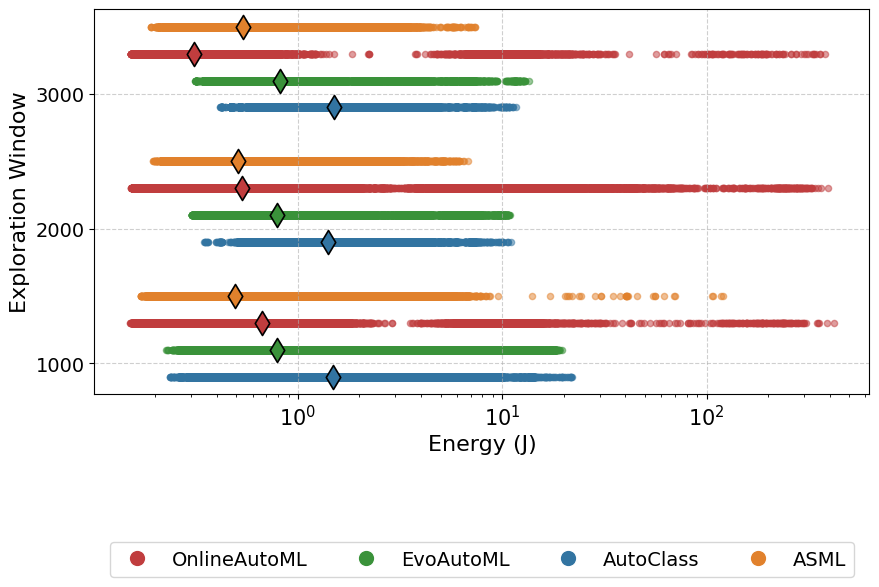

[1000, 2000, 3000]


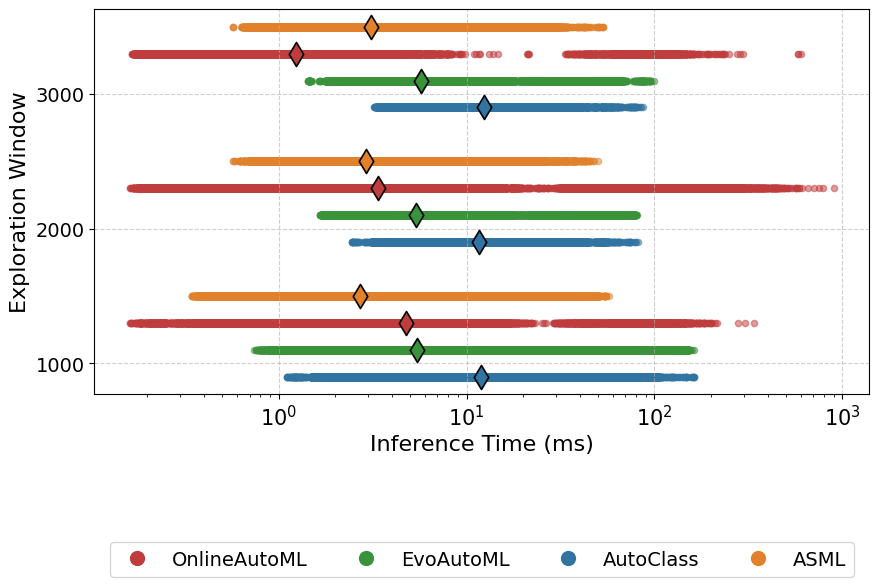

[1000, 2000, 3000]


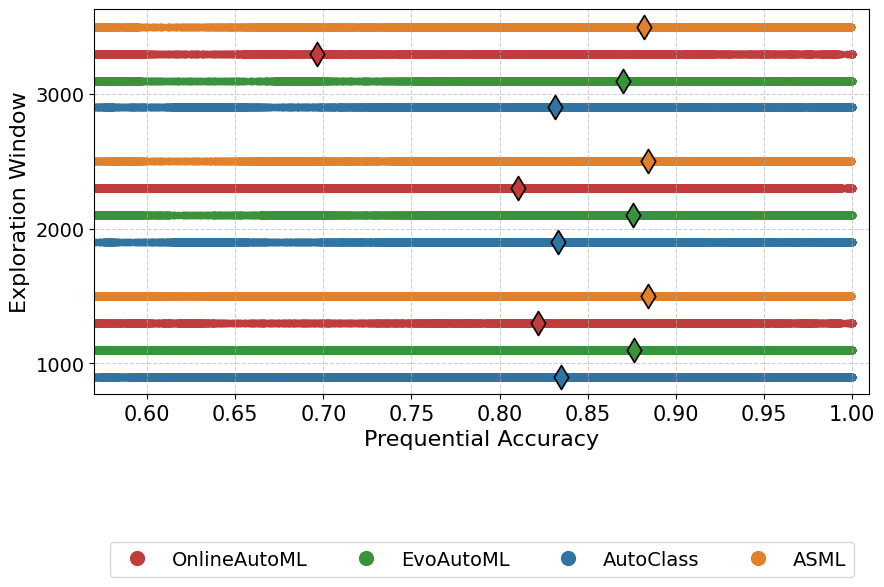

In [16]:
scatter_plot_configurations(['AutoClass','EvoAutoML','OnlineAutoML','AutoStreamML'],'energy_consumed','exploration_window')
scatter_plot_configurations(['AutoClass','EvoAutoML','OnlineAutoML','AutoStreamML'],'time','exploration_window')
scatter_plot_configurations(['AutoClass','EvoAutoML','OnlineAutoML','AutoStreamML'],'prequential_scores','exploration_window')


# Effect of population size

[5, 10, 20]


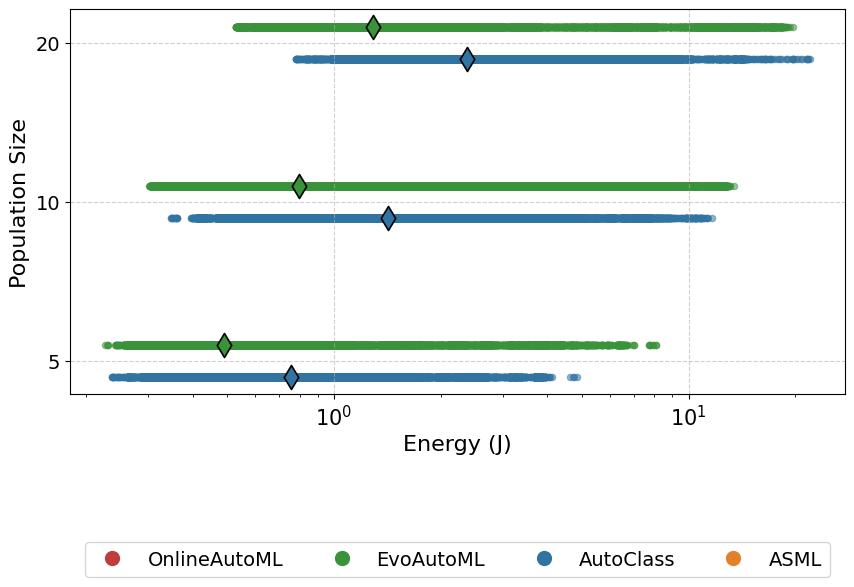

[5, 10, 20]


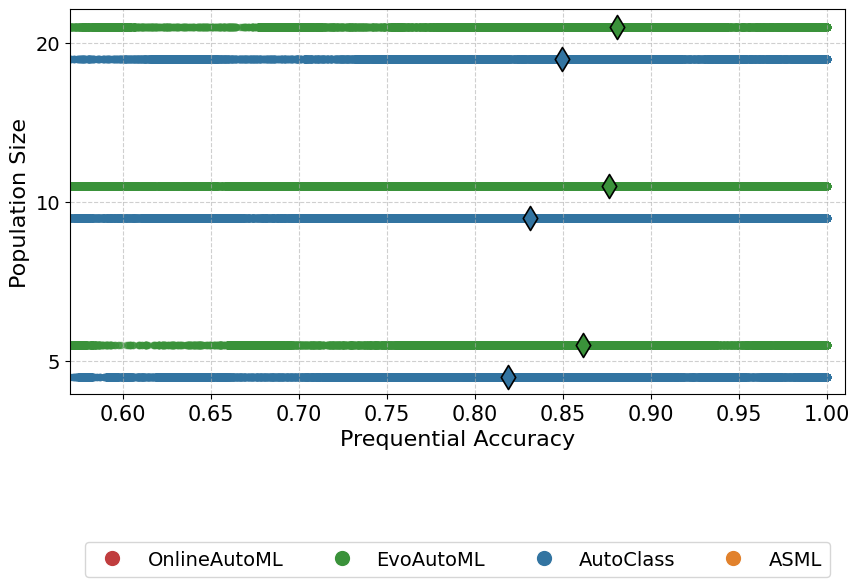

[5, 10, 20]


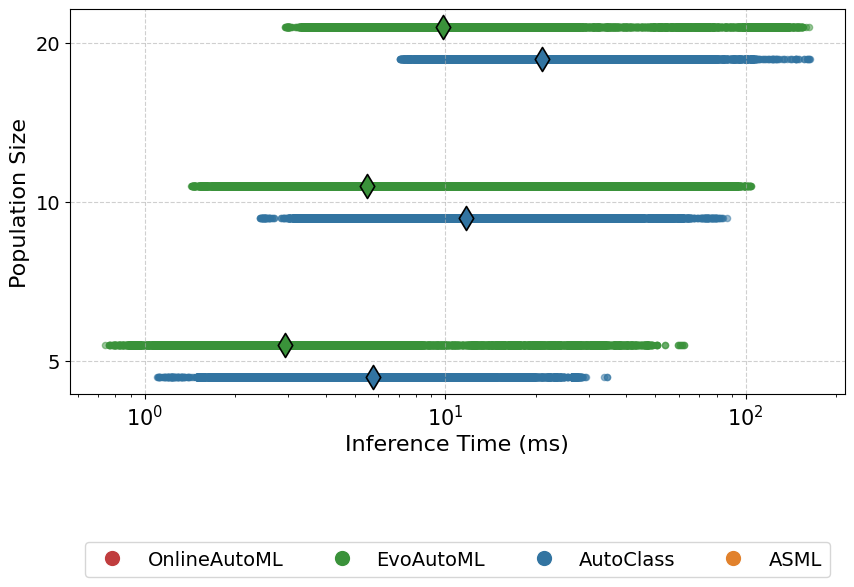

In [17]:
scatter_plot_configurations(['AutoClass','EvoAutoML'],'energy_consumed','population_size')
scatter_plot_configurations(['AutoClass','EvoAutoML'],'prequential_scores','population_size')
scatter_plot_configurations(['AutoClass','EvoAutoML'],'time','population_size')

# Effect of ensemble size

[2, 3, 4, 5, 10, 15]


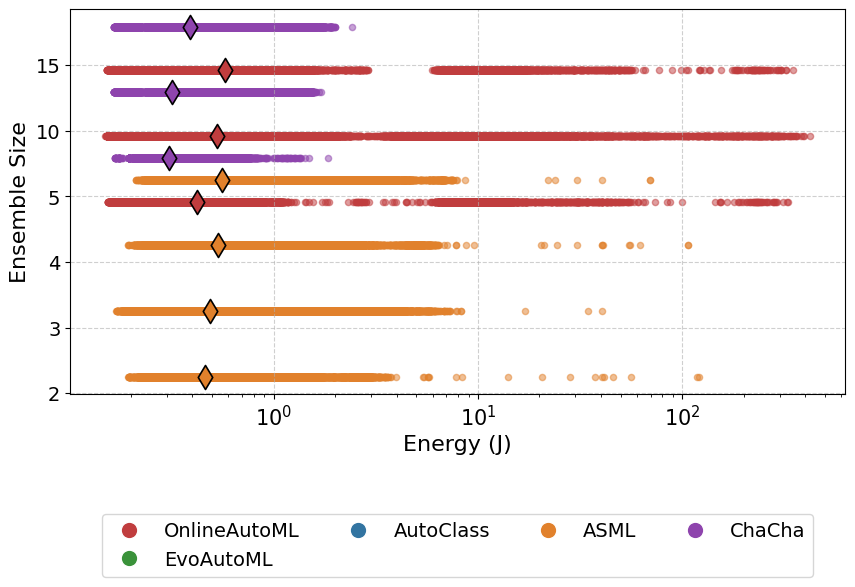

[2, 3, 4, 5, 10, 15]


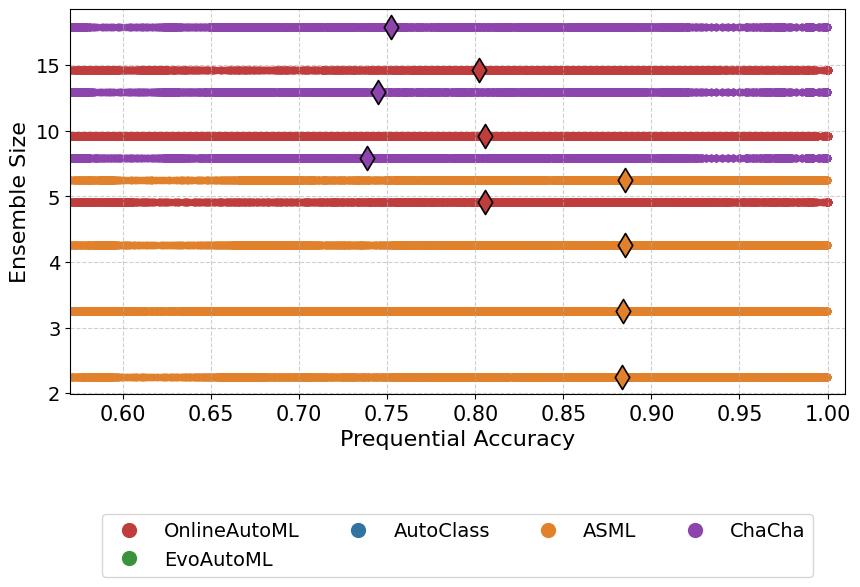

[2, 3, 4, 5, 10, 15]


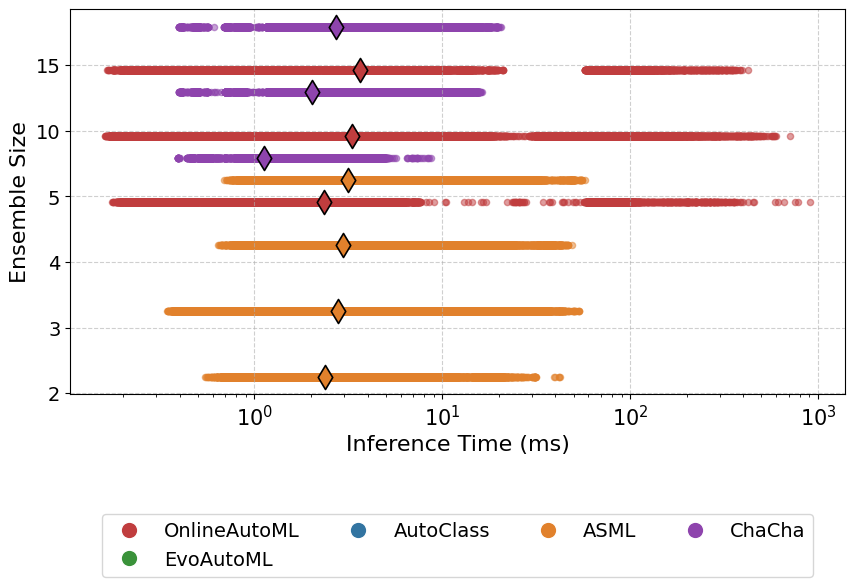

In [15]:
scatter_plot_configurations(['OnlineAutoML','AutoStreamML','ChaCha'],'energy_consumed','ensemble_size')
scatter_plot_configurations(['OnlineAutoML','AutoStreamML','ChaCha'],'prequential_scores','ensemble_size')
scatter_plot_configurations(['OnlineAutoML','AutoStreamML','ChaCha'],'time','ensemble_size')

### Visuals for model comparisions

In [2]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
from collections import defaultdict

# assumes downsample(...) exists in your environment

def process_file_3(args):
    """
    args can be:
       (path, group_value, model) or
       (path, group_value, model, parameter)

    Returns:
      (group_value, results_dict, model_or_None)

    results_dict keys: "prequential_scores", "energy_consumed", "time"
    """
    if len(args) == 3:
        path, group_value, model = args
        parameter = None
    elif len(args) == 4:
        path, group_value, model, parameter = args
    else:
        raise ValueError(f"process_file_3 expects 3 or 4 items in args, got {len(args)}")

    results = {
        "prequential_scores": [],
        "energy_consumed": [],
        "time": []
    }

    try:
        with open(path, 'r') as f:
            data = json.load(f)

        for metric in results.keys():
            if metric in data and data[metric] is not None:
                vals = np.array(data[metric], dtype=float)

                # unit conversions
                if metric == 'energy_consumed':
                    vals = vals * 3600000.0  # Wh -> J (keeps previous behavior)
                elif metric == 'time':
                    vals = vals * 1000.0     # s -> ms

                # downsample (keep your existing function)
                vals = downsample(vals, 1000)
                results[metric] = vals.tolist()

    except Exception as e:
        # keep error message but return empty lists (so caller can continue)
        print(f"Error reading {path if 'path' in locals() else 'unknown'}: {e}")

    return group_value, results, model


def scatter_plot_special_model(model, parameter):
    """
    Single plot with y-axis = metric names (Accuracy, Energy, Time),
    x-axis = metric values.
    Each parameter configuration is a different color, shifted on y-axis
    by +/-0.5 to avoid overlap.
    """

    canonical_param, aliases = get_all_param_aliases(parameter)

    # --- Build tasks ---
    tasks = []
    for dataset, models in dataset_by_model.items():
        if model in models:
            file_paths = models[model]
            for alias in aliases:
                pattern = rf'{alias}_(\d+)'
                for path in file_paths:
                    match = re.search(pattern, path)
                    if match:
                        group_value = int(match.group(1))
                        tasks.append((path, group_value, model, parameter))

    if not tasks:
        raise ValueError(f"No files found for model={model}, parameter={parameter}")

    # --- Collect results ---
    grouped_values = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    with multiprocessing.Pool(processes=4) as pool:
        for group_value, results_dict, mdl in pool.map(process_file_3, tasks):
            if mdl is None:
                continue
            for metric, values in results_dict.items():
                if values:
                    grouped_values[group_value][mdl][metric].extend(values)

    sorted_params = sorted(grouped_values.keys())
    if not sorted_params:
        raise ValueError("No metric data collected.")

    # --- Clip outliers ---
    for p in sorted_params:
        for mdl in grouped_values[p]:
            for metric in grouped_values[p][mdl]:
                v = np.array(grouped_values[p][mdl][metric], dtype=float)
                if v.size > 0:
                    grouped_values[p][mdl][metric] = np.clip(v, None, np.percentile(v, 100))

    # --- Plotting ---
    # --- Plotting ---
    metrics = ["prequential_scores", "energy_consumed", "time"]
    y_labels = ["Prequential Accuracy", "Energy", "Inference Time"]

    cmap = plt.cm.get_cmap("Dark2")
    colors = {p: cmap(i % cmap.N) for i, p in enumerate(sorted_params)}

    fig, ax_main = plt.subplots(figsize=(12, 6))

    spacing = 1.0
    offsets = np.linspace(-0.4, 0.4, len(sorted_params))

    # keep track of extra axes
    ax_energy = ax_main.twiny()
    ax_time   = ax_main.twiny()

    # vertical offsets for extra axes
    ax_energy.spines["top"].set_position(("axes", -0.20))   # below Accuracy
    ax_time.spines["top"].set_position(("axes", 1.0))      # above Inference Time

    # if model=='OnlineAutoML':
    ax_energy.set_xscale("log")
        # ax_energy.set_xlim(-4 , 30)  

    # hide spines not used
    for a in [ax_energy, ax_time]:
        a.spines["bottom"].set_visible(False)

    ax_main.tick_params(axis="x", labelsize=15)
    ax_energy.tick_params(axis="x", labelsize=15)
    ax_time.tick_params(axis="x", labelsize=15)


    # scatter plots per metric
    for i, metric in enumerate(metrics):
        for j, param_val in enumerate(sorted_params):
            if model not in grouped_values[param_val]:
                continue
            vals = np.array(grouped_values[param_val][model].get(metric, []), dtype=float)
            if vals.size == 0:
                continue

            y = np.full(vals.shape, i * spacing + offsets[j])

            # choose axis
            if metric == "prequential_scores":
                ax = ax_main
            elif metric == "energy_consumed":
                ax = ax_energy
            elif metric == "time":
                ax = ax_time

            ax.scatter(vals, y,
                       color=colors[param_val],
                       alpha=0.4,
                       s=20,
                       label=str(param_val) if i == 0 else "")

            median_val = np.median(vals)
            ax.scatter(median_val, i * spacing + offsets[j],
                       color=colors[param_val],
                       s=80,
                       marker="D",
                       edgecolor="black",
                       linewidth=1.0,
                       zorder=5)

    # --- Y axis ---
    ax_main.set_yticks([i * spacing for i in range(len(metrics))])
    ax_main.set_yticklabels(y_labels, fontsize=15)

    # --- Labels for different axes ---
    # --- Labels for different axes ---
    ax_main.set_xlabel("Accuracy", fontsize=15)
    ax_energy.set_xlabel("Energy", fontsize=15, labelpad=-40)   # pushed lower
    ax_time.set_xlabel("Inference Time", fontsize=15)  # pushed a bit up

    # ax_main.set_ylabel("Metrics", fontsize=14)
    # ax_main.set_title(f"{model} — performance across {canonical_param.replace('_',' ').title()}",
    #                   fontsize=16)

    # Legend (once per param)
    handles, labels = ax_main.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax_main.legend(by_label.values(), by_label.keys(),
                       title=canonical_param.replace('_', ' ').title(),
                       ncol=3,
                       bbox_to_anchor=(1.02, 1),
                       loc='upper left', fontsize=13)

    # grid on main axis
    ax_main.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [3]:
from collections import defaultdict
import multiprocessing
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def scatter_plot_special_model_final(models_and_params):
    """
    models_and_params: list of (model, parameter) tuples, e.g.
      [("EvoAutoML", "sampling_size"),
       ("AutoStreamML", "budget"),
       ("OnlineAutoML", "time_budget")]
    """
    metrics = ["prequential_scores", "energy_consumed", "time"]
    x_labels = ["Prequential Accuracy", "Energy", "Inference Time"]

    cmap = plt.cm.get_cmap("Dark2")
    colors = {}

    # === collect rows & data ===
    y_labels = [
    "EvoAutoML Sample Size 1",
    "EvoAutoML Sample Size 2",
    "EvoAutoML Sample Size 3",
    "ASML Budget 5",
    "ASML Budget 10",
    "ASML Budget 15",
    "OnlineAutoML Time Budget 30",
    "OnlineAutoML Time Budget 60",
    "OnlineAutoML Time Budget 90",
]
    grouped_all = {}  # key: (model, param_val) -> dict(metric -> values)
    insertion_keys = []  # preserve row insertion order
    spacing = 0.3       # vertical spacing between rows

    # pretty display names for parameters
    pretty_param_names = {
        "sampling_size": "Sample Size",
        "budget": "Budget",
        "time_budget": "Time Budget"
    }

    # build data
    for model, parameter in models_and_params:
        canonical_param, aliases = get_all_param_aliases(parameter)

        # collect tasks (same logic you had)
        tasks = []
        for dataset, models in dataset_by_model.items():
            if model in models:
                file_paths = models[model]
                for alias in aliases:
                    pattern = rf'{alias}_(\d+)'
                    for path in file_paths:
                        match = re.search(pattern, path)
                        if match:
                            group_value = int(match.group(1))
                            tasks.append((path, group_value, model, parameter))

        grouped_values = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
        if tasks:
            with multiprocessing.Pool(processes=4) as pool:
                for group_value, results_dict, mdl in pool.map(process_file_3, tasks):
                    if mdl is None:
                        continue
                    for metric, values in results_dict.items():
                        if values:
                            grouped_values[group_value][mdl][metric].extend(values)

        sorted_params = sorted(grouped_values.keys())
        for param_val in sorted_params:
            # use pretty label instead of raw param name
            pretty_param = pretty_param_names.get(parameter, parameter)
            label = f"{model} {pretty_param} {param_val}"
            # y_labels.append(label)
            key = (model, param_val)
            insertion_keys.append(key)
            grouped_all[key] = grouped_values[param_val][model]
            if param_val not in colors:
                colors[param_val] = cmap(len(colors) % cmap.N)

    if len(insertion_keys) == 0:
        raise ValueError("No data found for given models_and_params")

    # map keys -> y positions
    y_ticks = np.arange(len(y_labels)) * spacing
    y_positions = {k: y_ticks[i] for i, k in enumerate(insertion_keys)}

    # === build figure & axes (boxed style) ===
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(30, max(5, len(insertion_keys) * spacing * 0.4)),
        sharey=False,
        gridspec_kw={"wspace": 0.01}
    )
    fig.subplots_adjust(left=0.28, right=0.92, top=0.95, bottom=0.08)


    # === plotting ===
    for i, (metric, ax) in enumerate(zip(metrics, axes)):
        ax.tick_params(axis="x", labelsize=12)
    
        if i == 0:
            ax.set_yticks(y_ticks, labels=y_labels, fontsize=14)
            # ax.set_xlim(0.57,1.01)
        else:
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([])
    
        for key, metrics_dict in grouped_all.items():
            vals = np.array(metrics_dict.get(metric, []), dtype=float)
            if vals.size == 0:
                continue
            y = np.full(vals.shape, y_positions[key])
    
            ax.scatter(vals, y, color=colors[key[1]], alpha=0.45, s=18)
            median_val = np.median(vals)
            ax.scatter(median_val, y_positions[key], color=colors[key[1]],
                       s=60, marker="D", edgecolor="black", linewidth=0.8, zorder=5)
    
        ax.set_xlabel(x_labels[i], fontsize=16)
        ax.grid(True, axis="x", linestyle="--", alpha=0.5)
    
        # 🔑 Apply log scale for energy and inference time
        if metric in ["energy_consumed", "time"]:
            ax.set_xscale("log")
    
        for spine in ax.spines.values():
            spine.set_visible(True)
    
        ax.relim()
        ax.autoscale_view()




    plt.show()




# Effect of special hyperparameter

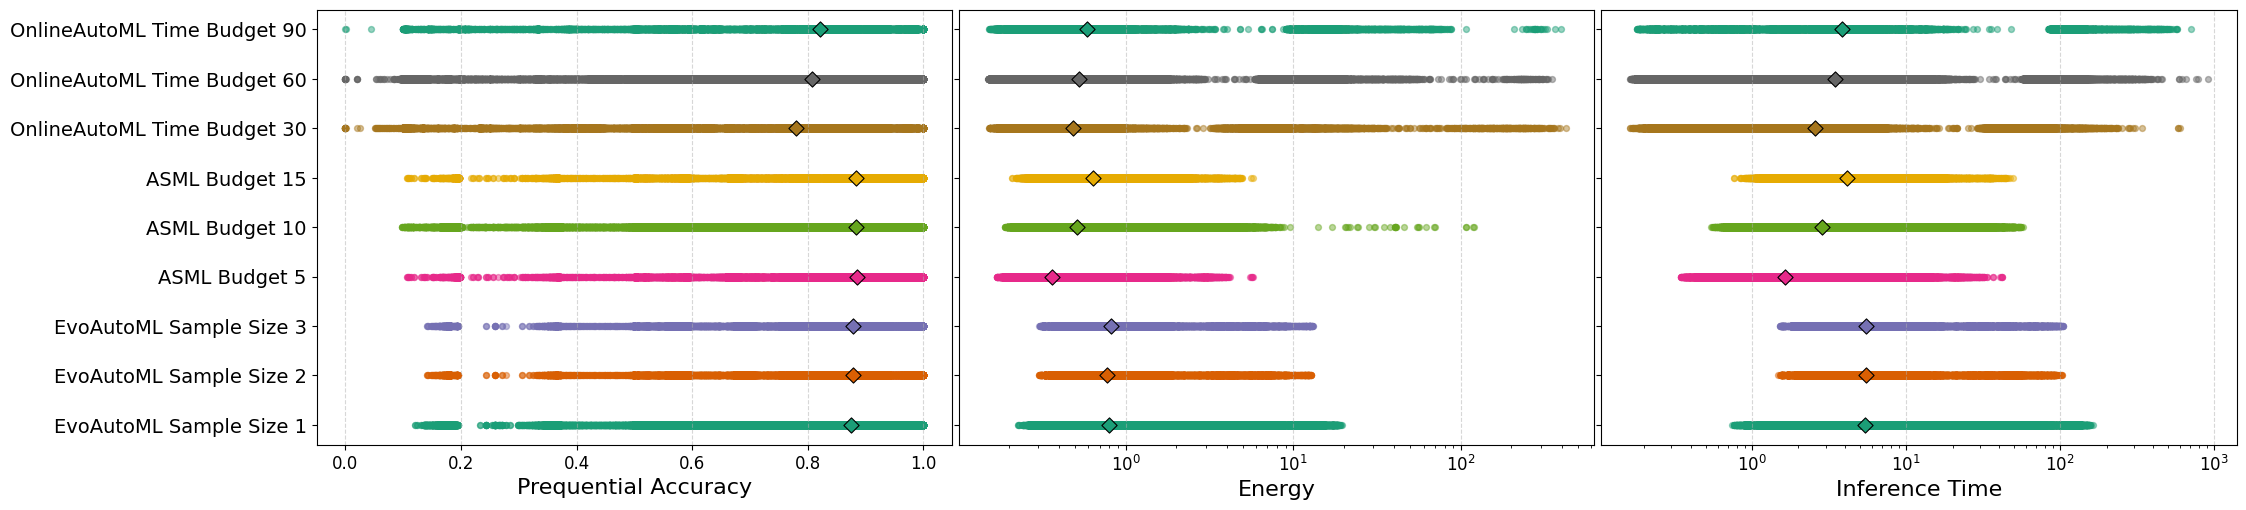

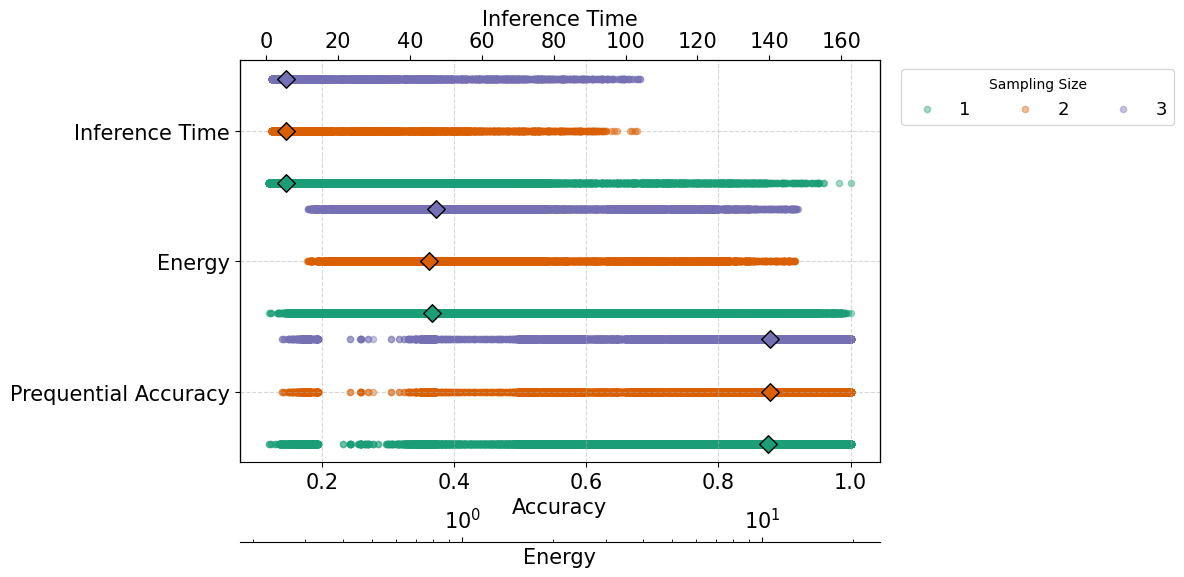

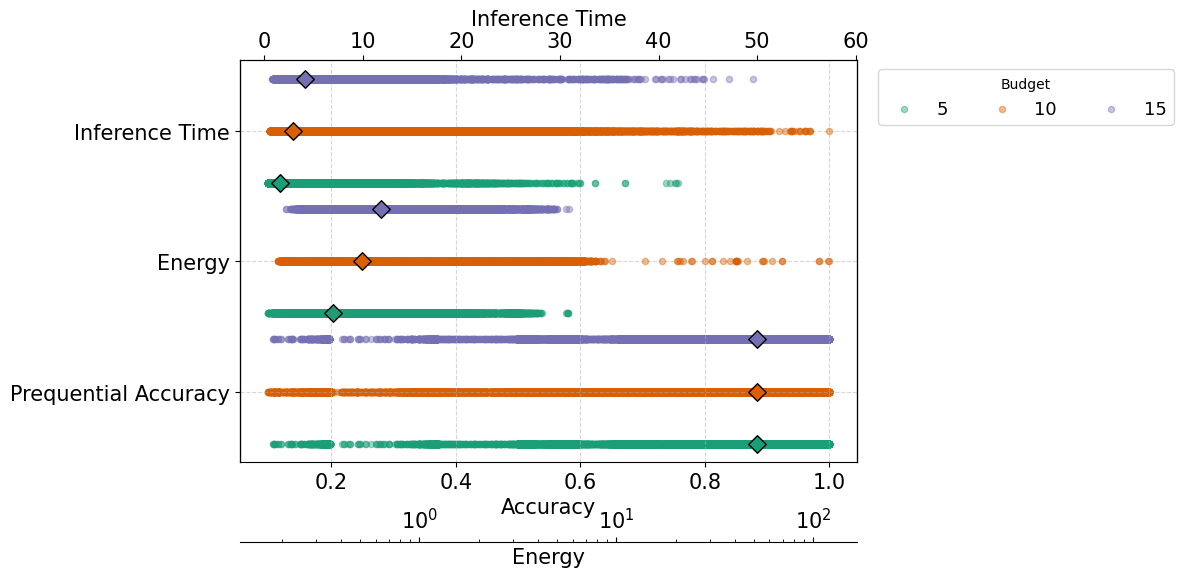

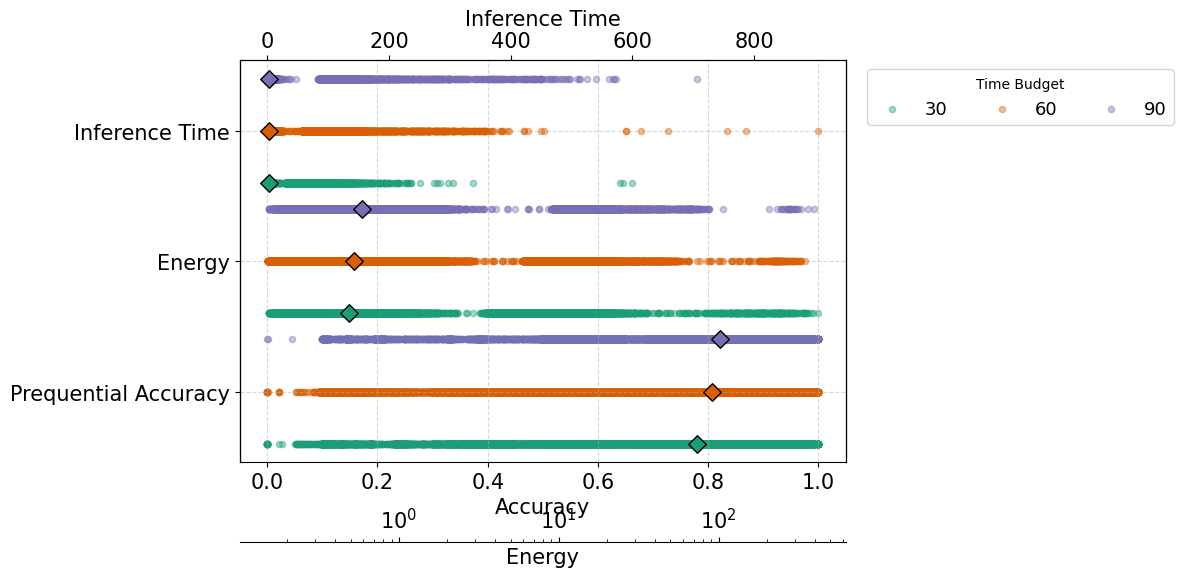

In [21]:
scatter_plot_special_model_final([
    ("EvoAutoML", "sampling_size"),
    ("AutoStreamML", "budget"),
    ("OnlineAutoML", "time_budget"),
])

scatter_plot_special_model('EvoAutoML','sampling_size')
scatter_plot_special_model('AutoStreamML','budget')
scatter_plot_special_model('OnlineAutoML','time_budget')

In [6]:
def kappa_no_chan_probs(window_size, class_values):
    class_values = np.array(class_values)  # Ensure it's a NumPy array
    num_class = len(np.unique(class_values))
    
    no_change_probabilities = []
    
    for start in range(0, len(class_values) - window_size + 1, window_size):
        end = start + window_size
        window_class_values = class_values[start:end]
    
        transitions = 0.0
    
        for j in range(num_class):
            transition = np.sum((window_class_values[:-1] == j) & (window_class_values[1:] == j))
            transitions += transition
        
        probability = transitions / (len(window_class_values) - 1) if len(window_class_values) > 1 else 0
        no_change_probabilities.append(probability)
    
    return np.array(no_change_probabilities)

def kappa_chan_probs(window_size, class_values):
    num_class = len(class_values.unique())  # Number of unique classes
    total_instances = len(class_values)     # Total number of instances
    
    # Calculate marginal probabilities of each class
    marginal_probs = class_values.value_counts(normalize=True).values
    
    # Expected agreement (accuracy of random chance classifier)
    expected_agreement = np.sum(marginal_probs ** 2)
    
    
    # Compute chance accuracy per window
    no_change_probabilities = []
    # class_values = np.array(class_values)  # Convert to numpy array for slicing
    
    for start in range(0, len(class_values) - window_size + 1, window_size):
        window = class_values[start:start + window_size]
        marginal_probs = window.value_counts(normalize=True).values
        expected_agreement = np.sum(marginal_probs ** 2)
        
        # Compute frequency of each class in the window
        window_counts = np.bincount(window, minlength=num_class)
    
        window_probs = window_counts / window_size
    
        # Compute probability of a random classifier being correct in this window
        no_change_prob = np.sum(window_probs ** 2)
        no_change_probabilities.append(no_change_prob)
    
    return np.array(no_change_probabilities)
    
def downsample(data, window_size):
    """Averages every `window_size` instances."""
    n = len(data) // window_size * window_size  # Trim to multiple of window_size
    return data[:n].reshape(-1, window_size).mean(axis=1)

def convert_snake_case_to_title_case(snake_case_string):
    """
    Converts a snake_case string to Title Case.

    Args:
        snake_case_string: The input string in snake_case.

    Returns:
        The string converted to Title Case.
    """
    if snake_case_string=='movingRBF':#1
        return 'Moving RBF'
    elif snake_case_string== 'synth_agrawal':#2
        return 'Agrawal'
    elif snake_case_string== 'vehicle_sensIT':#3
        return 'Vehicle SensIT'
    elif snake_case_string== 'sea_high_abrupt_drift':#4
        return 'SEA High Abrupt Drift'
    elif snake_case_string== 'sea_high_mixed_drift':#5
        return 'SEA High Gradual Drift'
    elif snake_case_string== 'synth_RandomRBFDrift':#7
        return 'Random RBF'
    elif snake_case_string== 'hyperplane_high_gradual_drift':
        return 'Hyperlane Gradual Drift'
    else:
        words = snake_case_string.split('_')
        title_case_words = [word.capitalize() for word in words]
        return ' '.join(title_case_words)

In [41]:
import json
import numpy as np
import matplotlib.pyplot as plt





def plot_drift(drift_case,type=None):
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",'#8e44ad']
    
    default_config=True
    
    fig, axes = plt.subplots(1, 2, figsize=(35, 13))

    
    dataset_list=drift_case
    
    for model, color in zip(model_names, colors):
        kappa_no_change_all = []
        kappa_chance_all = []
    
        for data_name in dataset_list:
            real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
            class_values = real_dataset['class']
            window_size = 1000 # if len(class_values) < 105000 else 10000
            threshold = int(len(class_values) - window_size)
            class_values = class_values[:threshold]
    
            no_change_probabilities = kappa_no_chan_probs(window_size=window_size, class_values=class_values)
            chance_probabilities = kappa_chan_probs(window_size=window_size, class_values=class_values)
    
            for sample in dataset_by_model[data_name][model]:
                # filter configs
                if default_config:
                    if model=='AutoClass' and 'population_size_10_exploration_window_1000' not in sample: continue
                    if model=='AutoStreamML' and 'exploration_window_1000_ensemble_size_3_budget_10' not in sample: continue
                    if model=='EvoAutoML' and 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample: continue
                    if model=='OnlineAutoML' and 'default' not in sample: continue
                    if model in ['SRPC','ARFC','HATC'] and 'nmodel_3' not in sample: continue
    
                with open(sample) as f:
                    data = json.load(f)
    
                prequential_scores = np.array(data['prequential_scores'])
                if len(prequential_scores) < threshold:
                    continue
                prequential_scores = prequential_scores[:threshold]
                prequential_scores = downsample(prequential_scores, window_size)
    
                # compute kappas for THIS run
                kappa_nc = (prequential_scores - no_change_probabilities) / (1 - no_change_probabilities)
                kappa_ch = (prequential_scores - chance_probabilities) / (1 - chance_probabilities)
    
                kappa_no_change_all.append(kappa_nc)
                kappa_chance_all.append(kappa_ch)
    
        # pad all runs to same length
        max_len = max(len(s) for s in kappa_no_change_all)
        def pad(arr_list):
            arr = np.full((len(arr_list), max_len), np.nan)
            for i, s in enumerate(arr_list):
                arr[i, :len(s)] = s
            return arr
    
        kappa_nc_arr = pad(kappa_no_change_all)
        kappa_ch_arr = pad(kappa_chance_all)
    
        # mean & std
        mean_nc, std_nc = np.nanmean(kappa_nc_arr, axis=0), np.nanstd(kappa_nc_arr, axis=0)
        mean_ch, std_ch = np.nanmean(kappa_ch_arr, axis=0), np.nanstd(kappa_ch_arr, axis=0)
    
        x = np.arange(len(mean_nc)) * window_size
        short_name = {
            'OnlineAutoML': 'OnlineAutoML',
            'AutoClass': 'AutoClass',
            'AutoStreamML': 'ASML',
            'EvoAutoML': 'EvoAutoML'
        }.get(model, model)

        if type == "G":
            fig.suptitle("Gradual Drift", fontsize=40)
            lines=[20000,10000,19000,23000]
            for pos in lines:
                axes[0].axvline(pos, color="black", linestyle="--", linewidth=3)
                axes[1].axvline(pos, color="black", linestyle="--", linewidth=3)

        elif type == "A":
            fig.suptitle("Abrupt Drift", fontsize=40)
            lines=[20000,15000,30000,25000,27000]
            for pos in lines:
                axes[0].axvline(pos, color="black", linestyle="--", linewidth=3)
                axes[1].axvline(pos, color="black", linestyle="--", linewidth=3)
        else:
            fig.suptitle("Incremental Drift", fontsize=40)
    
        axes[0].plot(x, mean_nc, color=color, linewidth=4, label=short_name)
        # axes[0].set_ylim(-2, 2)
        # axes[0].fill_between(x, mean_nc-std_nc, mean_nc+std_nc, color=color, alpha=0.2)

#         axes[0].plot(
#     x, mean_nc - std_nc,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
#         axes[0].plot(
#     x, mean_nc + std_nc,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
    
        axes[1].plot(x, mean_ch, color=color, linewidth=4, label=short_name)
        # axes[1].ylim(-2,2)
        # axes[1].fill_between(x, mean_ch-std_ch, mean_ch+std_ch, color=color, alpha=0.2)

#         axes[1].plot(
#     x, mean_ch - std_ch,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
#         axes[1].plot(
#                     x, mean_ch + std_ch,
#                     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
        # std_kwargs = dict(
        # linestyle=(0, (5, 2)),  # long dash, short gap
        # linewidth=1.4,
        # alpha=0.9
        # )
        
        # axes[0].plot(x, mean_nc - std_nc, color=color, **std_kwargs)
        # axes[0].plot(x, mean_nc + std_nc, color=color, **std_kwargs)
        
        # axes[1].plot(x, mean_ch - std_ch, color=color, **std_kwargs)
        # axes[1].plot(x, mean_ch + std_ch, color=color, **std_kwargs)
    
    for i, title in enumerate(["$\kappa^+$", "$\kappa$"]):
        axes[i].set_xlabel("Instance number", fontsize=30)
        axes[i].set_ylabel(title, fontsize=30)
        axes[i].tick_params(axis='both', labelsize=30)
        axes[i].grid(True, color='0.8' ,alpha=1.0, linewidth=2.5)

    
    # fig.legend(loc="lower center", ncol=5, fontsize=25, bbox_to_anchor=(0.5, -0.17))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=8, fontsize=25, bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout()
    plt.show()




# Kappa visualisations on drift type

In [ ]:
real_datasets=[
    'adult',
    'electricity',
    'forest_cover',
    'insects',
   	'new_airlines',
    'shuttle',
    'vehicle_sensIT',
    'rialto',
    'weather',
]

A_drift=[
    'skmul_ledgenerator', #20/1
    'river_SEA_2', #15/1
    # 'sea_high_abrupt_drift', 
    # 'sea_high_mixed_drift',
    'skmul_randomTree', #15/1
    'river_randomTree', #30/1
    'river_SINE', #25/1
    'river_Waveform', #27/1
    'river_STAGGER', #25
    'river_mixed' #20
]

I_drift=[
    'synth_RandomRBFDrift',
    'river_randomRBF_drift',
    'movingRBF'
]

G_drift = [
    # 'hyperplane_high_gradual_drift',
    # 'moving_squares',
    # 'river_SEA',
    'river_Waveform_2', #23/10
    # 'river_aggrawal',
    # 'river_anomalysine',
    # 'river_hyperlane',
    'river_hyperlane_2', #20/20
    # 'river_led',
    # 'river_led_default_drift',
    # 'river_randomRBF',
    'river_randomRBF_2', #19/10
    'river_randomTree_2', #12/9
    # 'skmul_SEA',
    'skmul_SEA_2', #20/10
    # 'skmul_STAGGER',
    'skmul_STAGGER_2', #15/15
    # 'skmul_Sine',
    # 'skmul_Waveform',
    # 'skmul_aggrawal',
    # 'skmul_anomalysine', 
    'skmul_anomalysine_2', #10/10
    # 'skmul_hyperlane',
    # 'skmul_ledgenerator_default_drift', 
    # 'skmul_randomRBF_default_drift',
    # 'skmul_randomRBF_gradual',
    'skmul_randomTree_2', #12/9
    # 'synth_agrawal'
 ]

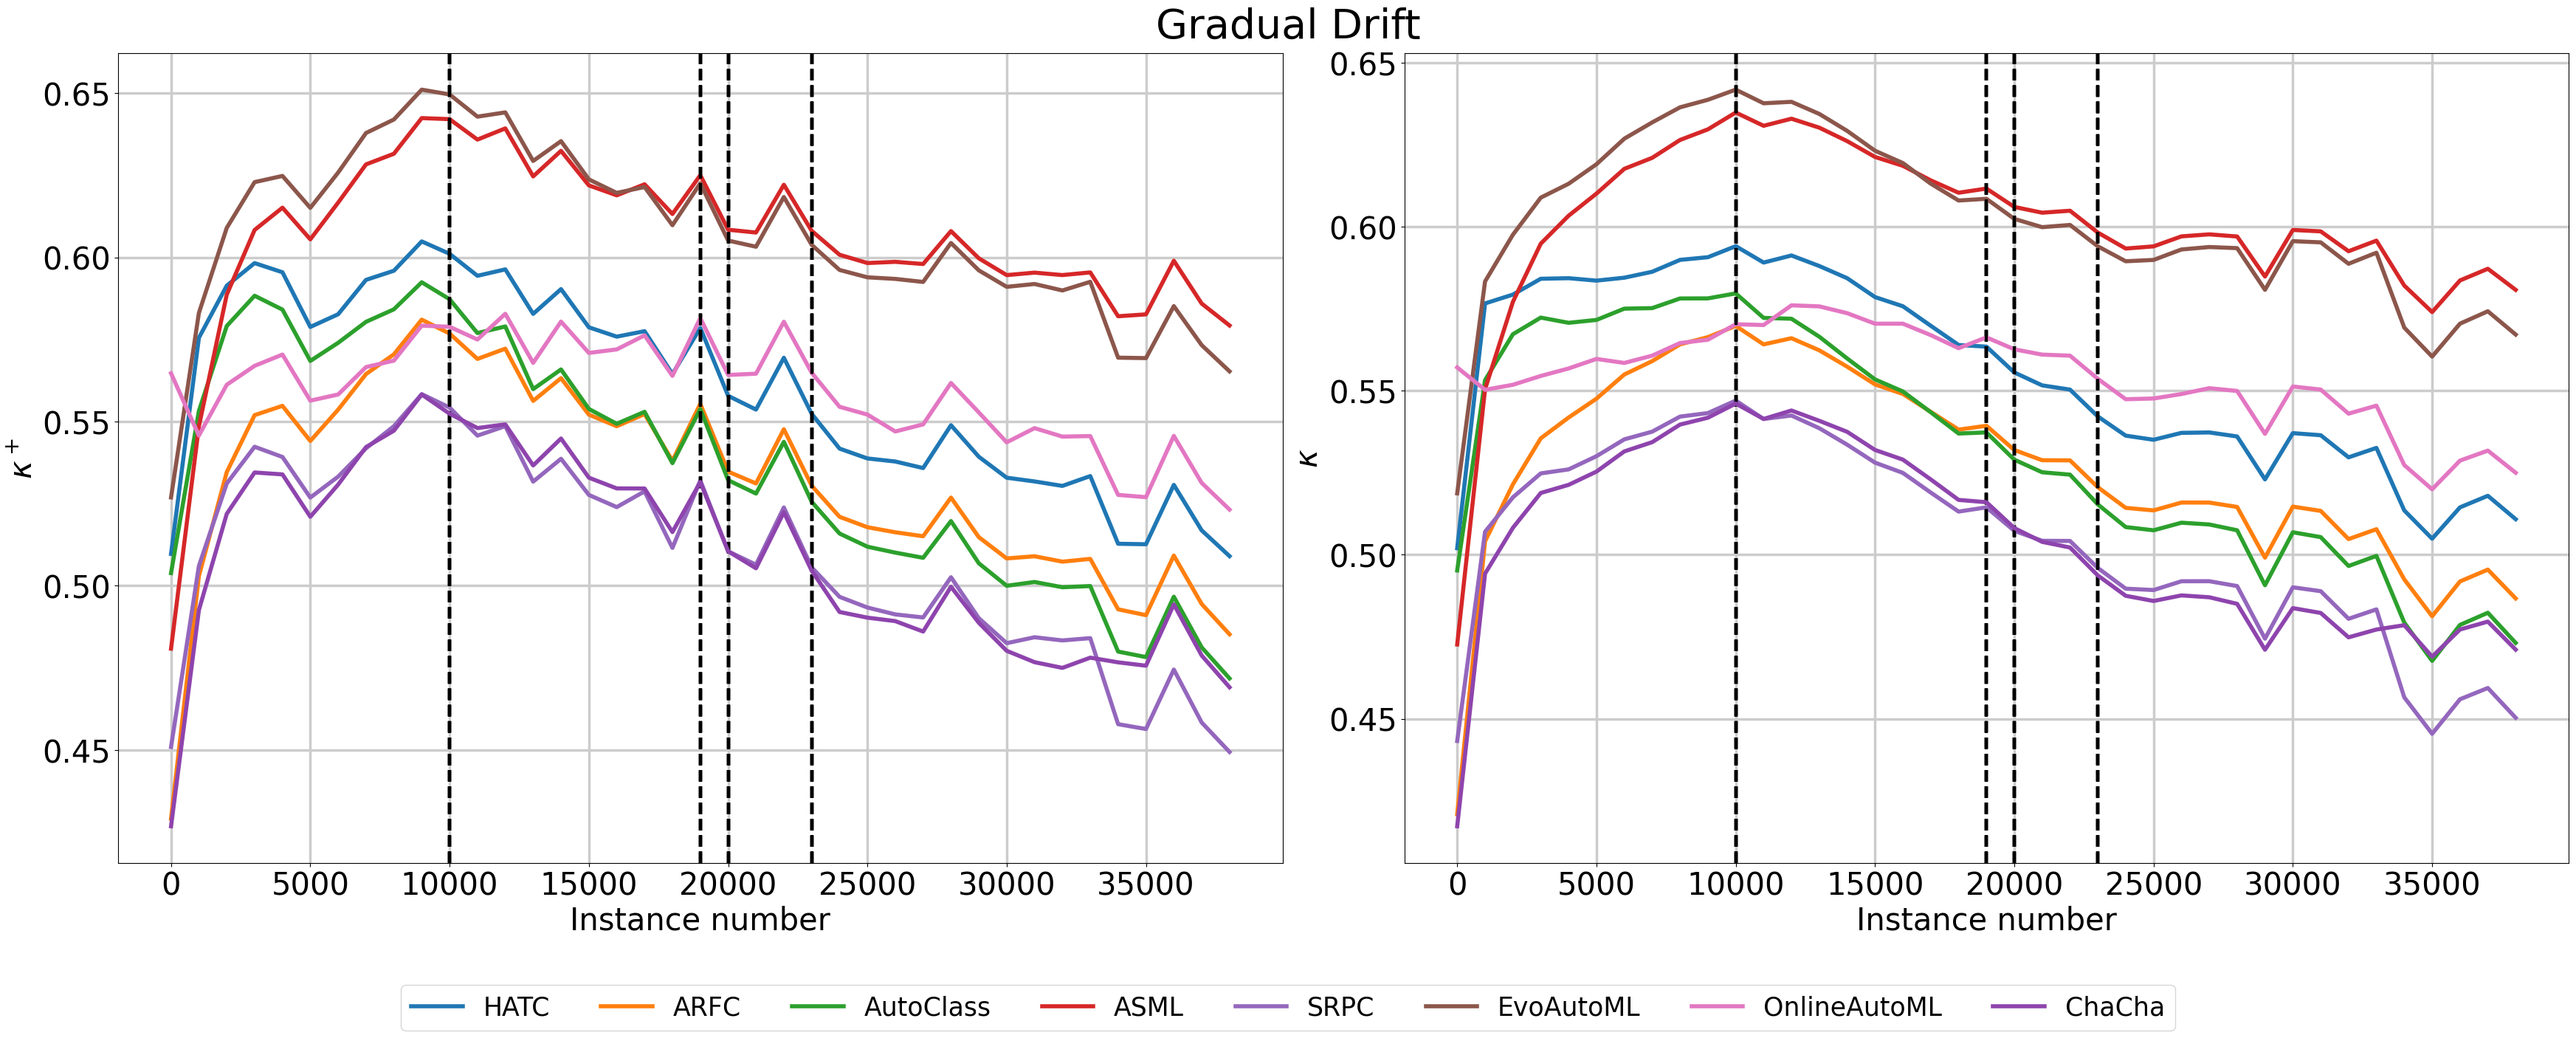

In [42]:
#plot_drift(A_drift,'A')
#plot_drift(I_drift)
plot_drift(G_drift,'G')

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_dataset_pair(
    datasets,
    default_config=True,
):


    colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#9467bd", "#8c564b", "#e377c2"
    ]

    fig, axes = plt.subplots(3, 1, figsize=(20, 30))
    plt.grid(True)
    linestyles = ['solid', 'solid']
    markers = ['^', 'X']

    for data_idx, data_name in enumerate(datasets):
        real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
        class_values = real_dataset['class']

        window_size = 1000 if len(class_values) < 80000 else 10000
        threshold = int(len(class_values) - window_size)
        class_values = class_values[:threshold]

        no_change_probabilities = kappa_no_chan_probs(window_size=window_size, class_values=class_values)
        chance_probabilities = kappa_chan_probs(window_size=window_size, class_values=class_values)

        for model, color in zip(model_names, colors):
            all_scores, all_time, all_energy, all_emission = [], [], [], []

            for sample in dataset_by_model[data_name][model]:
                if default_config:
                    # Model configuration filters
                    if model == 'AutoClass' and 'population_size_10_exploration_window_1000' not in sample:
                        continue
                    if model == 'AutoStreamML' and 'exploration_window_1000_ensemble_size_3_budget_10' not in sample:
                        continue
                    if model == 'EvoAutoML' and 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample:
                        continue
                    if model == 'OnlineAutoML' and 'default' not in sample:
                        continue
                    if model in ['SRPC', 'ARFC', 'HATC'] and 'nmodel_3' not in sample:
                        continue

                with open(sample) as f:
                    data = json.load(f)

                prequential_scores = np.array(data['prequential_scores'])
                time = np.array(data['time'])
                energy_consumed = np.array(data['energy_consumed'])
                carbon_emissioned = np.array(data['emission'])

                if len(prequential_scores) < threshold:
                    continue

                # Truncate arrays to match threshold
                prequential_scores = prequential_scores[:threshold]
                time = time[:threshold]
                energy_consumed = energy_consumed[:threshold]
                carbon_emissioned = carbon_emissioned[:threshold]

                all_scores.append(prequential_scores)
                all_time.append(time)
                all_energy.append(energy_consumed)
                all_emission.append(carbon_emissioned)

            # Compute means and standard deviations
            all_scores, all_time, all_energy, all_emission = (
                np.array(all_scores),
                np.array(all_time),
                np.array(all_energy),
                np.array(all_emission),
            )

            mean_scores, std_scores = np.mean(all_scores, axis=0), np.std(all_scores, axis=0)
            mean_time, std_time = np.mean(all_time, axis=0), np.std(all_time, axis=0)
            mean_energy, std_energy = np.mean(all_energy, axis=0), np.std(all_energy, axis=0)
            mean_emission, std_emission = np.mean(all_emission, axis=0), np.std(all_emission, axis=0)

            # Downsample
            mean_scores = downsample(mean_scores, window_size)
            mean_time = downsample(mean_time, window_size)
            mean_energy = downsample(mean_energy, window_size)
            mean_emission = downsample(mean_emission, window_size)

            std_scores = downsample(std_scores, window_size)
            std_time = downsample(std_time, window_size)
            std_energy = downsample(std_energy, window_size)
            std_emission = downsample(std_emission, window_size)

            # Unit conversions
            mean_energy *= 3600000
            std_energy *= 3600000
            mean_time *= 1000
            std_time *= 1000

            x = np.arange(len(mean_scores)) * window_size
            linestyle = linestyles[data_idx]
            marker = markers[data_idx]

            # Plot metrics
            axes[0].plot(x, mean_scores, label=f"{model} ({convert_snake_case_to_title_case(data_name)})", color=color, linestyle=linestyle, marker=marker, markersize=10)
            axes[1].plot(x, mean_time, label=f"{model} ({convert_snake_case_to_title_case(data_name)})", color=color, linestyle=linestyle, marker=marker, markersize=10)
            axes[2].plot(x, mean_energy, label=f"{model} ({convert_snake_case_to_title_case(data_name)})", color=color, linestyle=linestyle, marker=marker, markersize=10)

    # Final formatting
    for i, title in enumerate(["Accuracy", "Inference Time", "Energy"]):
        axes[i].set_xlabel("Instance number", fontsize=25)
        axes[i].set_title(
            f"{title} on {convert_snake_case_to_title_case(datasets[0])} and {convert_snake_case_to_title_case(datasets[1])} datasets",
            fontsize=25
        )
        axes[i].tick_params(axis='both', labelsize=25)
        axes[i].grid(True)

    axes[2].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.8), fontsize=25)
    plt.show()


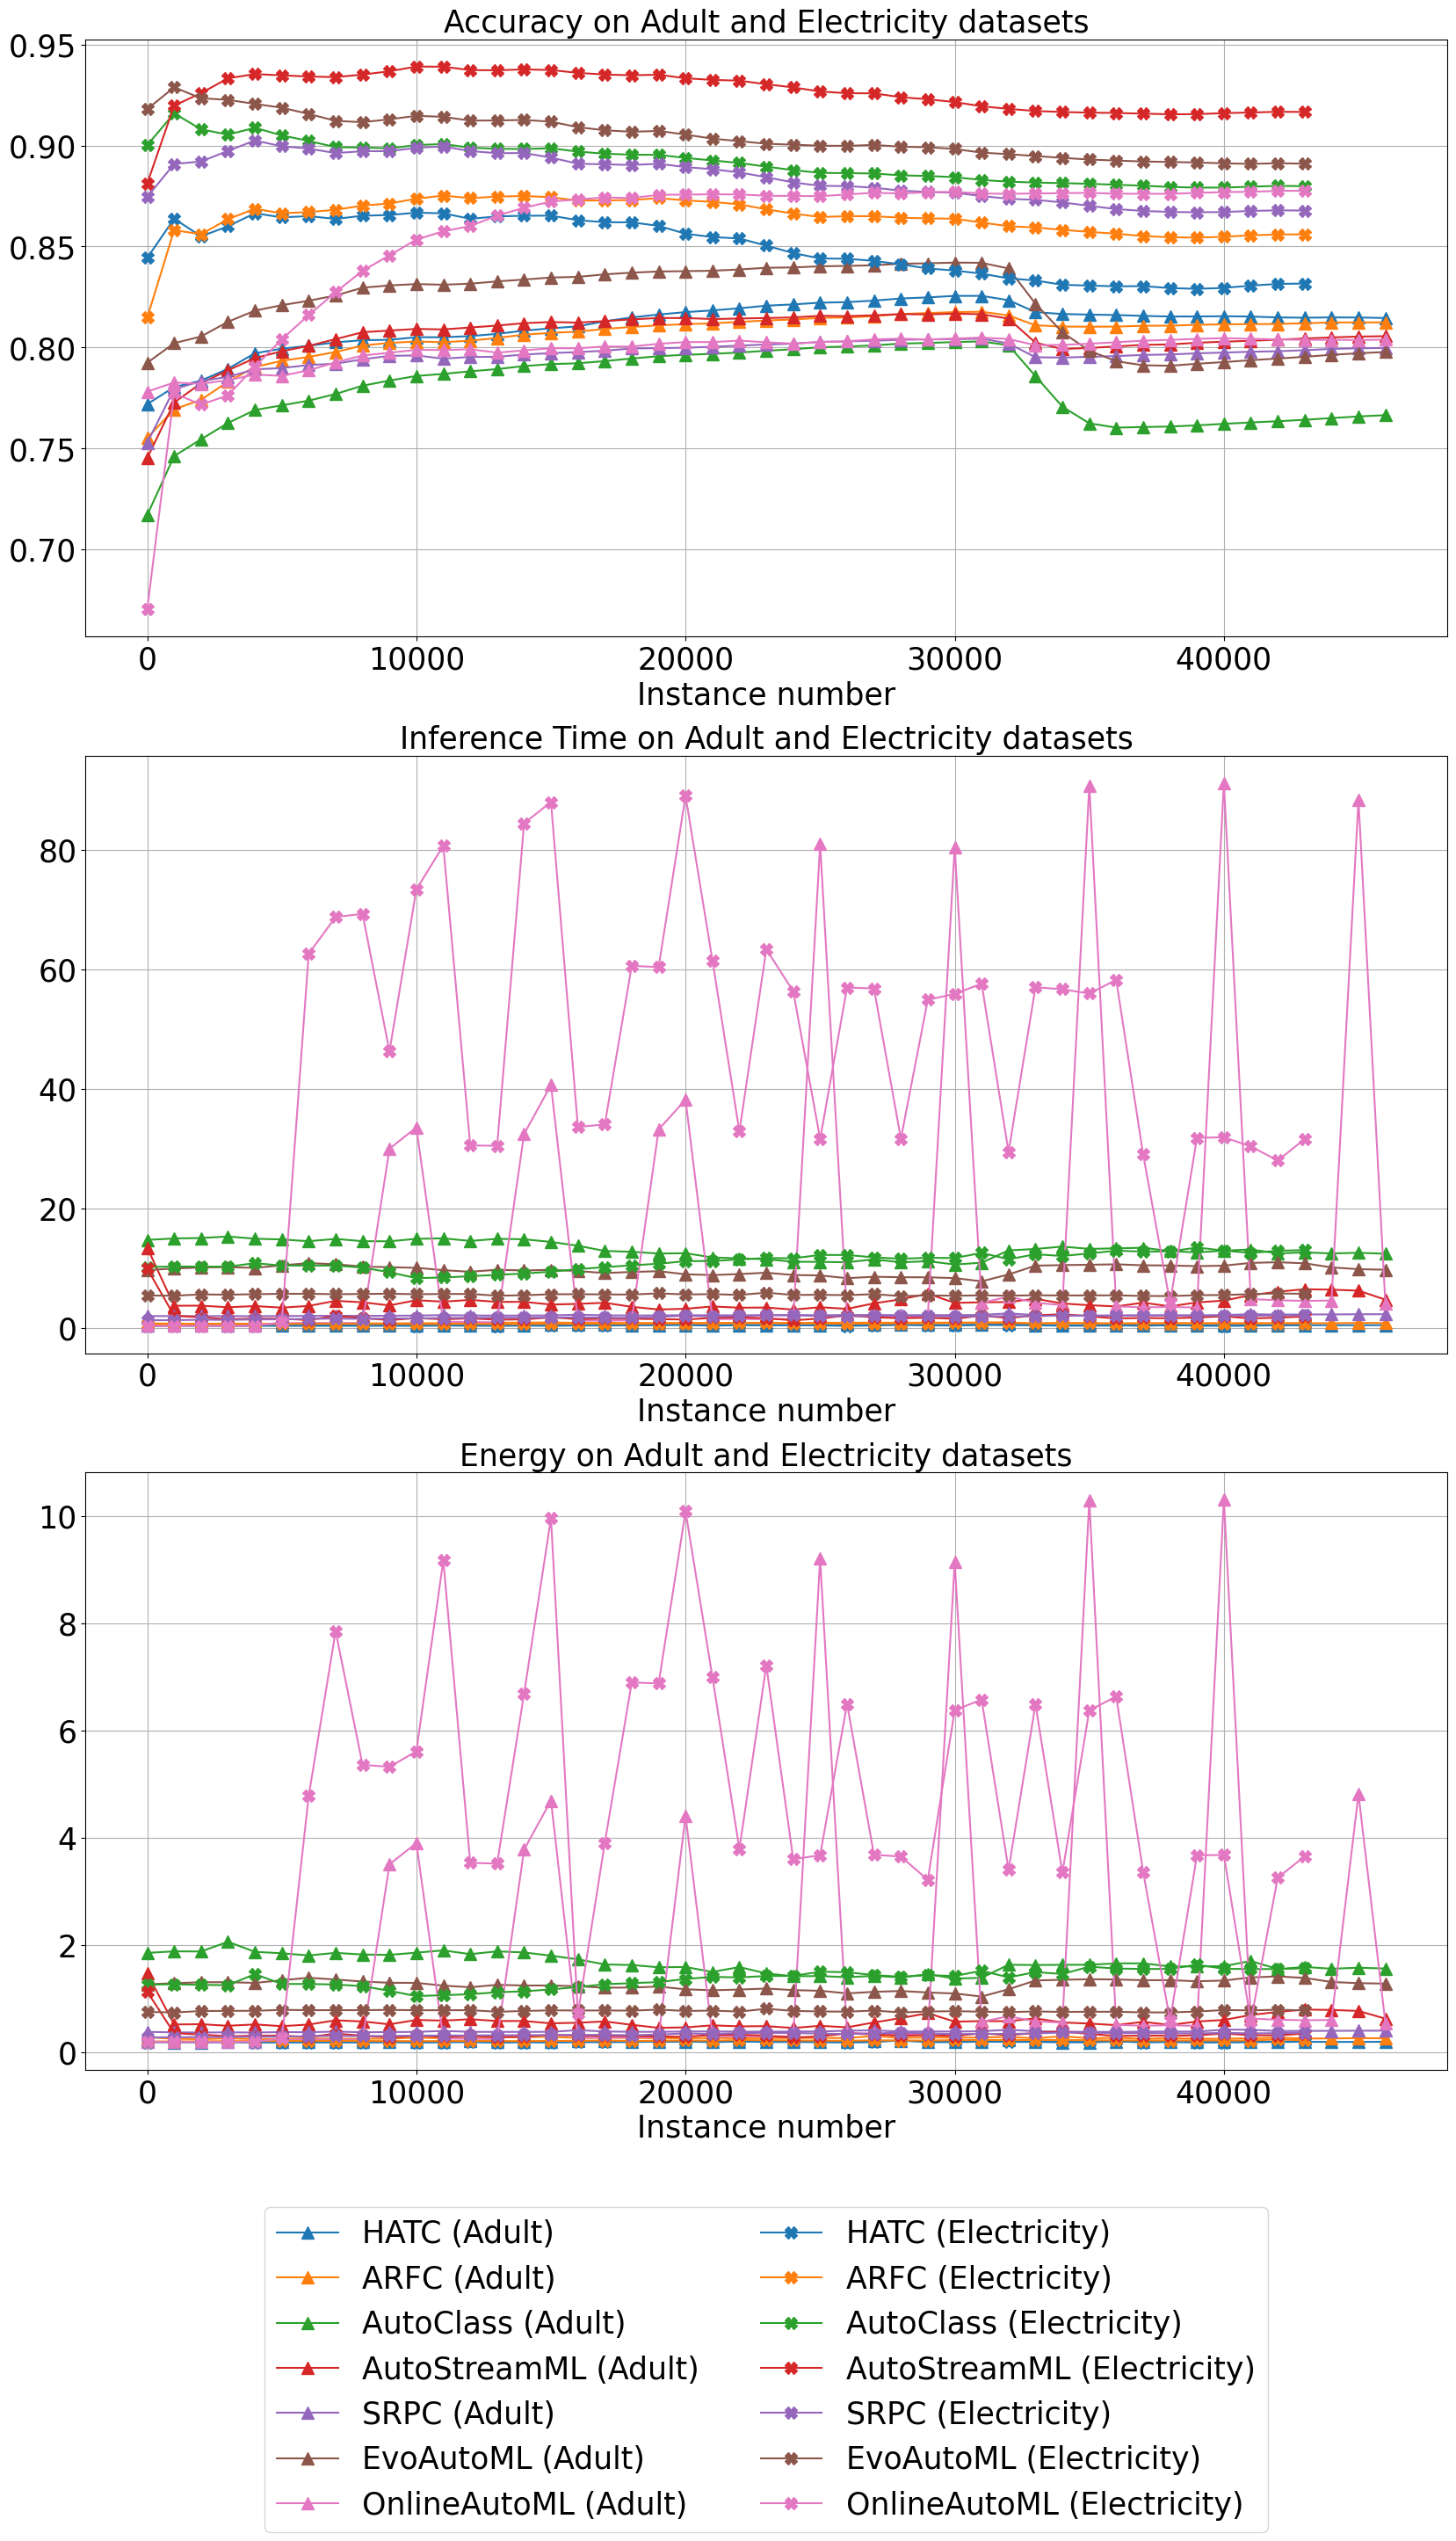

In [10]:
plot_dataset_pair(
    ['adult', 'electricity']
)

In [28]:
default_config=True

mean_scores_for_stat_test={}
for dataset in dataset_names:
    mean_scores_for_stat_test[dataset]={}

mean_energy_for_stat_test={}
for dataset in dataset_names:
    mean_energy_for_stat_test[dataset]={}

mean_time_for_stat_test={}
for dataset in dataset_names:
    mean_time_for_stat_test[dataset]={}

model_names_for_stats=('AutoClass','AutoStreamML','EvoAutoML',"OnlineAutoML")

for data_idx, data_name in enumerate(dataset_names):

    real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
    class_values = real_dataset['class']
    if len(class_values)>100000:
        window_size=10000
    else:
        window_size=1000


    
    threshold = int(len(class_values) - window_size)

    
    class_values=class_values[:threshold]
    
    for model in model_names:

        all_scores, all_time, all_energy, all_emission = [], [], [], []

        for sample in dataset_by_model[data_name][model]:
            if default_config==True:
                if model=='AutoClass':
                    if 'population_size_10_exploration_window_1000' not in sample:
                        continue
                if model == 'AutoStreamML':
                    if 'exploration_window_1000_ensemble_size_3_budget_10' not in sample:
                        continue
                if model == 'EvoAutoML':
                    if 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample:
                        continue
                if model == 'OnlineAutoML':
                    if 'default' not in sample:
                        continue
                if model == 'SRPC' or model =='ARFC' or model=='HATC':
                    if 'nmodel_3' not in sample:
                        continue
            with open(sample) as f:
                data = json.load(f)

            prequential_scores = np.array(data['prequential_scores'])
            time = np.array(data['time'])
            energy_consumed = np.array(data['energy_consumed'])



            if len(prequential_scores) < threshold or len(time) < threshold or len(energy_consumed) < threshold:
                continue



            prequential_scores = prequential_scores[:threshold]
            time = time[:threshold]
            energy_consumed = energy_consumed[:threshold]
            # carbon_emissioned=carbon_emissioned[:threshold]


            prequential_scores=downsample(prequential_scores,window_size)
            time=downsample(time,window_size)
            energy_consumed=downsample(energy_consumed,window_size)

    
        # Append to the lists
            all_scores.append(prequential_scores)
            all_time.append(time)
            all_energy.append(energy_consumed)



        all_scores, all_time, all_energy, all_emission = np.array(all_scores), np.array(all_time), np.array(all_energy), np.array(all_emission)

        mean_scores, std_scores = np.mean(all_scores, axis=0), np.std(all_scores, axis=0)
        mean_time, std_time = np.mean(all_time, axis=0), np.std(all_time, axis=0)
        mean_energy, std_energy = np.mean(all_energy, axis=0), np.std(all_energy, axis=0)
        mean_emission, std_emission= np.mean(all_emission, axis=0), np.std(all_emission, axis=0)

        mean_scores_for_stat_test[data_name][model]=mean_scores
        mean_energy_for_stat_test[data_name][model]=mean_energy
        mean_time_for_stat_test[data_name][model]=mean_time




In [29]:
across_dataset_mean_scores_for_stat_test={}
across_dataset_mean_energy_for_stat_test={}
across_dataset_mean_time_for_stat_test={}

for mode in model_names_for_stats:
    stat_scores=[]
    stat_energy=[]
    stat_time=[]
    for datase in dataset_names:
        stat_scores.append(np.mean(mean_scores_for_stat_test[datase][mode],axis=0))
        stat_energy.append(np.mean(mean_energy_for_stat_test[datase][mode],axis=0))
        stat_time.append(np.mean(mean_time_for_stat_test[datase][mode],axis=0))
    across_dataset_mean_energy_for_stat_test[mode]=stat_energy
    across_dataset_mean_time_for_stat_test[mode]=stat_time
    across_dataset_mean_scores_for_stat_test[mode]=stat_scores

In [30]:
import numpy as np

across_dataset_concat_scores_for_stat_test = {}
across_dataset_concat_energy_for_stat_test = {}
across_dataset_concat_time_for_stat_test = {}

for mode in model_names:
    stat_scores = []
    stat_energy = []
    stat_time = []
    
    for dataset in dataset_names:
        stat_scores.extend(mean_scores_for_stat_test[dataset][mode])  # Concatenation
        stat_energy.extend(mean_energy_for_stat_test[dataset][mode])  # Concatenation
        stat_time.extend(mean_time_for_stat_test[dataset][mode])  # Concatenation
    
    across_dataset_concat_scores_for_stat_test[mode] = np.array(stat_scores)
    across_dataset_concat_energy_for_stat_test[mode] = np.array(stat_energy)
    across_dataset_concat_time_for_stat_test[mode] = np.array(stat_time)


## Wilcoxon statistical test

### For Inference Time

In [31]:
from scipy.stats import wilcoxon

for classifier_1 in model_names:
    for classifier_2 in model_names_for_stats:
        if classifier_1==classifier_2:
            continue
        else:
            mean_classifier_1=across_dataset_concat_time_for_stat_test[classifier_1]
            mean_classifier_2=across_dataset_concat_time_for_stat_test[classifier_2]
            statistic, p_value = wilcoxon(mean_classifier_1, mean_classifier_2)
        
            print(classifier_1, '---', classifier_2, '----', p_value)
            alpha = 0.05  # Significance level
            if p_value < alpha:
                # a=0
                print("There is a significant difference between the two frameworks.")
            else:
                print("There is no significant difference between the two frameworks.")
            print('-'*50)

HATC --- AutoClass ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- AutoStreamML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- EvoAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- OnlineAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoClass ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoStreamML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- EvoAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC

### Accuracy

In [32]:
from scipy.stats import wilcoxon

for classifier_1 in model_names:
    for classifier_2 in model_names_for_stats:
        if classifier_1==classifier_2:
            continue
        else:
            mean_classifier_1=across_dataset_concat_scores_for_stat_test[classifier_1]
            mean_classifier_2=across_dataset_concat_scores_for_stat_test[classifier_2]
            statistic, p_value = wilcoxon(mean_classifier_1, mean_classifier_2)
        
            print(classifier_1, '---', classifier_2, '----', p_value)
            alpha = 0.05  # Significance level
            if p_value < alpha:

                print("There is a significant difference between the two frameworks.")
            else:
                print("There is no significant difference between the two frameworks.")
            print('-'*50)

HATC --- AutoClass ---- 6.2155446289643976e-15
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- AutoStreamML ---- 7.451679979989987e-207
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- EvoAutoML ---- 5.389565165485383e-270
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- OnlineAutoML ---- 0.004543261152158847
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoClass ---- 4.49743347725243e-56
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoStreamML ---- 6.381158439881971e-295
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- EvoAutoML ---- 2.070949969

### Energy


In [33]:
from scipy.stats import wilcoxon

for classifier_1 in model_names:
    for classifier_2 in model_names_for_stats:
        if classifier_1==classifier_2:
            continue
        else:
            mean_classifier_1=across_dataset_concat_energy_for_stat_test[classifier_1]
            mean_classifier_2=across_dataset_concat_energy_for_stat_test[classifier_2]
            statistic, p_value = wilcoxon(mean_classifier_1, mean_classifier_2)
        
            print(classifier_1, '---', classifier_2, '----', p_value)
            alpha = 0.05  # Significance level
            if p_value < alpha:

                print("There is a significant difference between the two frameworks.")
            else:
                print("There is no significant difference between the two frameworks.")
            print('-'*50)

HATC --- AutoClass ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- AutoStreamML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- EvoAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
HATC --- OnlineAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoClass ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- AutoStreamML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC --- EvoAutoML ---- 0.0
There is a significant difference between the two frameworks.
--------------------------------------------------
ARFC

### Friedman statistical test

### Accuracy

In [34]:
from scipy.stats import friedmanchisquare

stat,p=friedmanchisquare(across_dataset_mean_scores_for_stat_test['AutoClass'],
                         across_dataset_mean_scores_for_stat_test['AutoStreamML'],
                         across_dataset_mean_scores_for_stat_test['EvoAutoML'],
                         across_dataset_mean_scores_for_stat_test['OnlineAutoML'])

alpha = 0.05  
if p_value < alpha:
        print("There is a significant difference between the frameworks.")
else:
    print("There is no significant difference between the frameworks.")

There is a significant difference between the frameworks.


### Inference Time

In [35]:
from scipy.stats import friedmanchisquare

stat,p=friedmanchisquare(across_dataset_mean_time_for_stat_test['AutoClass'],
                         across_dataset_mean_time_for_stat_test['AutoStreamML'],
                         across_dataset_mean_time_for_stat_test['EvoAutoML'],
                         across_dataset_mean_time_for_stat_test['OnlineAutoML'])

alpha = 0.05  
if p_value < alpha:
        print("There is a significant difference between frameworks.")
else:
    print("There is no significant difference between the frameworks.")

There is a significant difference between frameworks.


### Energy Consumption

In [36]:
from scipy.stats import friedmanchisquare

stat,p=friedmanchisquare(across_dataset_mean_energy_for_stat_test['AutoClass'],
                         across_dataset_mean_energy_for_stat_test['AutoStreamML'],
                         across_dataset_mean_energy_for_stat_test['EvoAutoML'],
                         across_dataset_mean_energy_for_stat_test['OnlineAutoML'])

alpha = 0.05  
if p_value < alpha:
        print("There is a significant difference between the frameworks.")
else:
    print("There is no significant difference between the frameworks.")

There is a significant difference between the frameworks.


In [37]:


default_config=True

model_scores = {}
model_time = {}
model_energy = {}
model_kappa = {}
model_kappa_plus = {}

# Initialize the dictionaries to hold data for each model
for model in model_names_for_stats:
    model_scores[model] = []
    model_time[model] = []
    model_energy[model] = []
    model_kappa[model] = []
    model_kappa_plus[model] = []

for data_idx, data_name in enumerate(dataset_names):

    real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
    class_values = real_dataset['class']
    if len(class_values)>100000:
        window_size=10000
    else:
        window_size=1000
    
    threshold = int(len(class_values) - window_size)
    class_values = class_values[:threshold]

    no_change_probabilities = kappa_no_chan_probs(window_size=window_size, class_values=class_values)
    chance_probabilities = kappa_chan_probs(window_size=window_size, class_values=class_values)

    for model in model_names_for_stats:

        
        for sample in dataset_by_model[data_name][model]:
            if default_config==True:
                if model == 'AutoClass':
                    if 'population_size_10_exploration_window_1000' not in sample:
                        continue
                if model == 'AutoStreamML':
                    if 'exploration_window_1000_ensemble_size_3_budget_10' not in sample:
                        continue
                if model == 'EvoAutoML':
                    if 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample:
                        continue
                if model == 'OnlineAutoML':
                    if 'default' not in sample:
                        continue
                if model == 'SRPC' or model =='ARFC' or model=='HATC':
                    if 'nmodel_3' not in sample:
                        continue

            with open(sample) as f:
                data = json.load(f)


            prequential_scores = np.array(data['prequential_scores'])
            time = np.array(data['time'])
            energy_consumed = np.array(data['energy_consumed'])

            if len(prequential_scores) < threshold or len(time) < threshold or len(energy_consumed) < threshold:
                continue

            prequential_scores = prequential_scores[:threshold]
            time = time[:threshold]
            energy_consumed = energy_consumed[:threshold]

            energy_consumed *= 3600000  # Convert to proper units
            time *= 1000  # Convert to milliseconds

            # Downsample the metrics
            down_prequential_scores = downsample(prequential_scores, window_size)
            down_time = downsample(time, window_size)
            down_energy_consumed = downsample(energy_consumed, window_size)

            # Trim the no_change_probabilities to match the downsampled scores length
            no_change_probabilities = no_change_probabilities[:len(down_prequential_scores)]

            # Calculate kappa values
            kappa_no_change_down = (down_prequential_scores - no_change_probabilities) / (1 - no_change_probabilities)
            kappa_chance_down = (down_prequential_scores - chance_probabilities) / (1 - chance_probabilities)


            model_scores[model] = np.concatenate([model_scores[model], down_prequential_scores])
            model_time[model] = np.concatenate([model_time[model], down_time])
            model_energy[model] = np.concatenate([model_energy[model], down_energy_consumed])
            model_kappa[model] = np.concatenate([model_kappa[model], kappa_no_change_down])
            model_kappa_plus[model] = np.concatenate([model_kappa_plus[model], kappa_chance_down])


### Framework to framework comparision

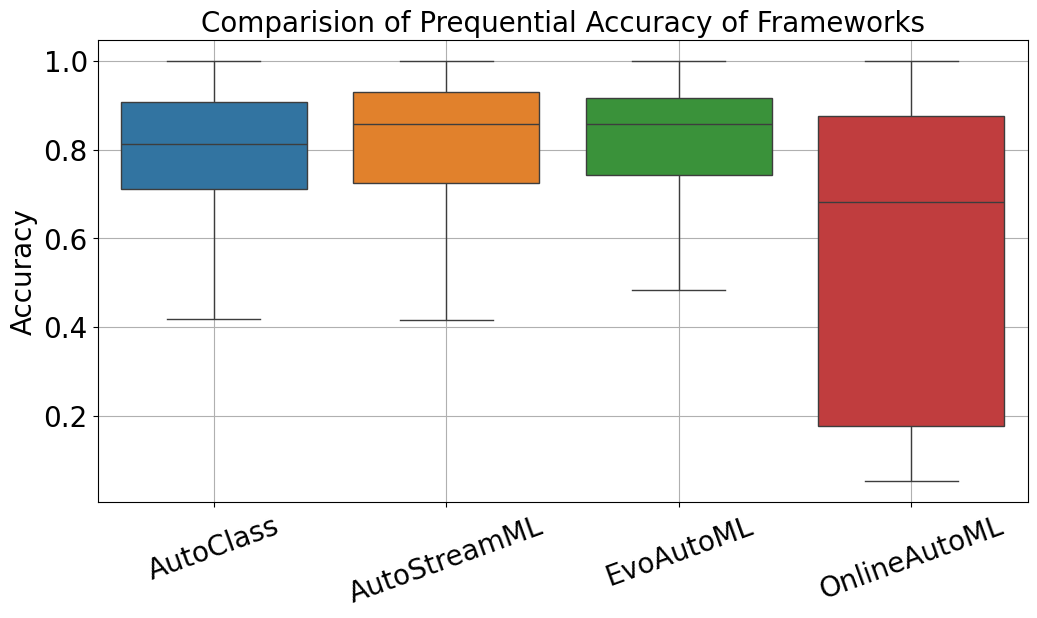

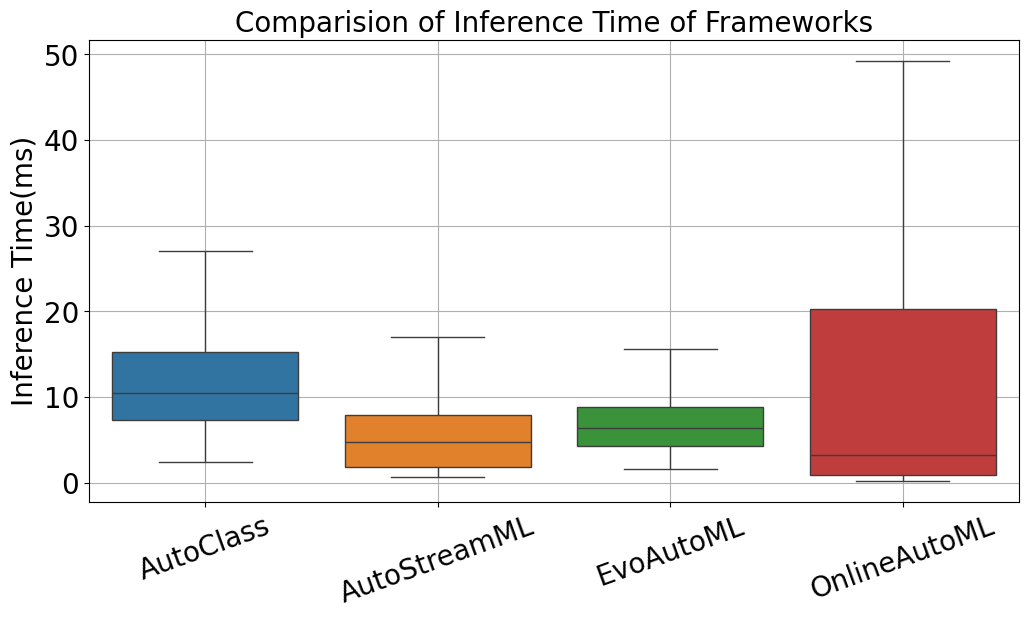

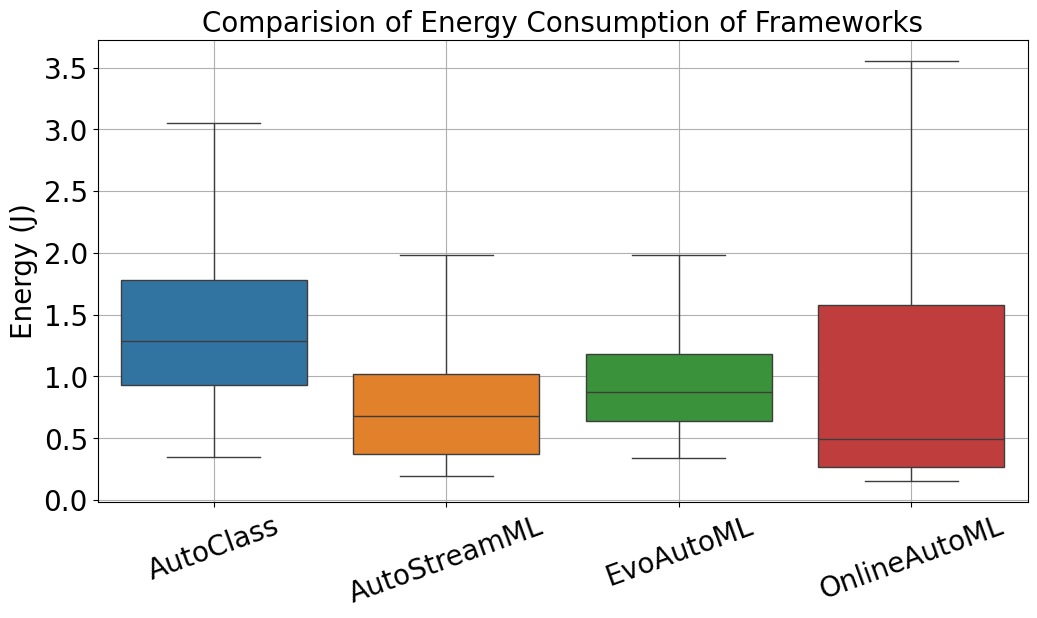

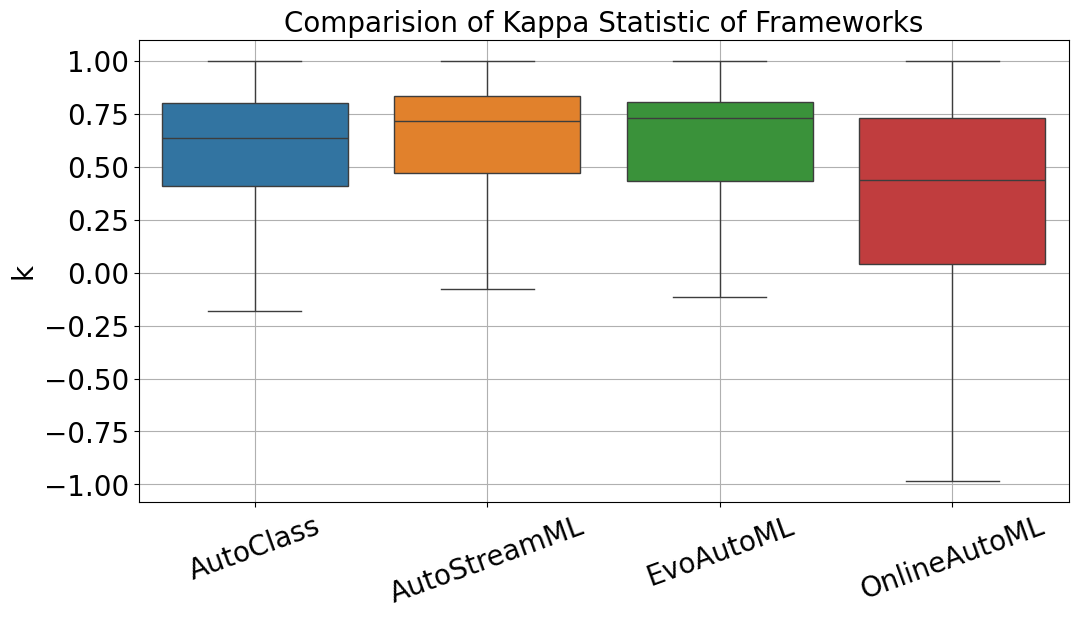

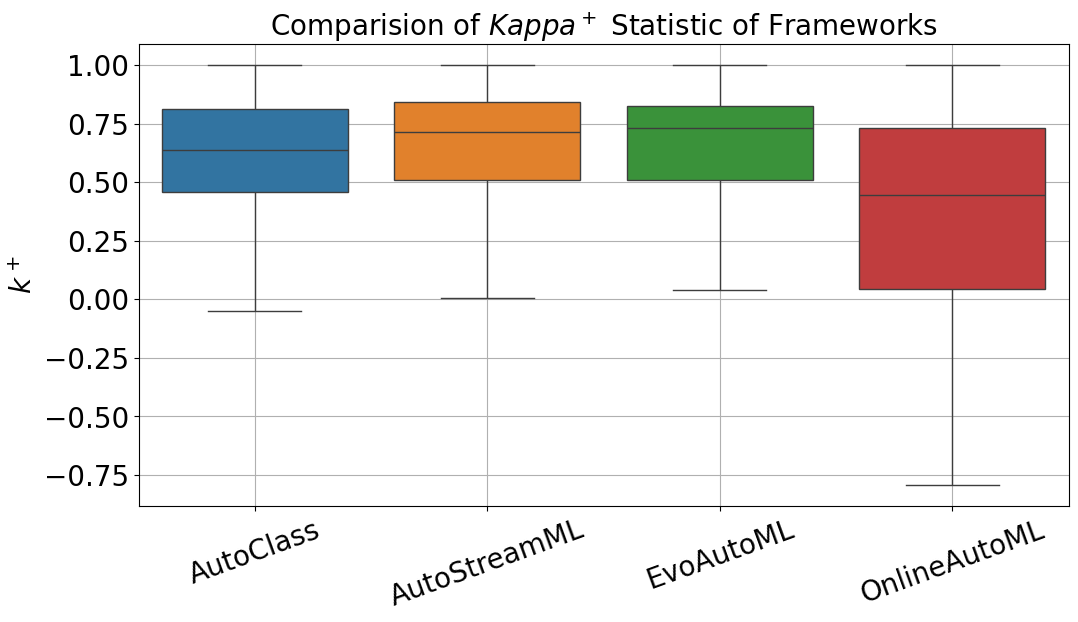

In [38]:
metrics = {
    'model_scores': model_scores,
    'model_time':  model_time,
    'model_energy': model_energy,
    'model_kappa': model_kappa,
    'model_kappa_plus': model_kappa_plus
}

# Loop over each metric
for metric_name, metric_data in metrics.items():
    # Flatten scores for all models
    all_scores = []
    model_labels = []

    for model, scores in metric_data.items():
        # flattened_scores = [score for sublist in scores for score in sublist]
        all_scores.append(scores)
        model_labels.append(model)

    # Create a boxplot for the current metric
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=all_scores, showfliers=False)
    titles={
        'model_scores': 'Comparision of Prequential Accuracy of Frameworks',
        'model_time': 'Comparision of Inference Time of Frameworks',
        'model_energy': 'Comparision of Energy Consumption of Frameworks',
        'model_kappa': 'Comparision of Kappa Statistic of Frameworks',
        'model_kappa_plus': 'Comparision of $Kappa^+$ Statistic of Frameworks'
    }
    y_labels={
        'model_scores': 'Accuracy',
        'model_time': 'Inference Time(ms)',
        'model_energy': 'Energy (J)',
        'model_kappa': 'k',
        'model_kappa_plus': '$k^+$'
    }
    

    # Add grid and increase font size
    plt.title(f'{titles.get(metric_name)}', fontsize=20)
    plt.ylabel(y_labels.get(metric_name), fontsize=20)
    # plt.ylabel(metric_name)
    plt.xticks(range(len(model_labels)), model_labels, fontsize=20,rotation=20)  # Increase font size for x-ticks
    plt.yticks(fontsize=20)  # Increase font size for y-ticks
    plt.grid(True)

    # Show the plot for this metric
    plt.show()

In [39]:
import numpy as np

for model in model_names_for_stats:
    # Convert to numpy arrays (if not already) and replace inf with NaN
    scores = np.array(model_scores[model], dtype=np.float64)
    time = np.array(model_time[model], dtype=np.float64)
    energy = np.array(model_energy[model], dtype=np.float64)
    kappa = np.array(model_kappa[model], dtype=np.float64)
    kappa_plus = np.array(model_kappa_plus[model], dtype=np.float64)

    # Replace infinity (inf) with NaN so nanmean/nanstd will ignore them
    scores[~np.isfinite(scores)] = np.nan
    time[~np.isfinite(time)] = np.nan
    energy[~np.isfinite(energy)] = np.nan
    kappa[~np.isfinite(kappa)] = np.nan
    kappa_plus[~np.isfinite(kappa_plus)] = np.nan

    # Compute mean and std (ignoring NaN and inf)
    mean_score, std_score = np.nanmean(scores), np.nanstd(scores)
    mean_time, std_time = np.nanmean(time), np.nanstd(time)
    mean_energy, std_energy = np.nanmean(energy), np.nanstd(energy)
    mean_kappa, std_kappa = np.nanmean(kappa), np.nanstd(kappa)
    mean_kappa_plus, std_kappa_plus = np.nanmean(kappa_plus), np.nanstd(kappa_plus)

    # Print results
    print(f"Model: {model}")
    print(f"  Scores → Mean: {mean_score:.2f}, Std: {std_score:.2f}")
    print(f"  Time → Mean: {mean_time:.2f}, Std: {std_time:.2f}")
    print(f"  Energy → Mean: {mean_energy:.2f}, Std: {std_energy:.2f}")
    print(f"  Kappa → Mean: {mean_kappa:.2f}, Std: {std_kappa:.2f}")
    print(f"  Kappa+ → Mean: {mean_kappa_plus:.2f}, Std: {std_kappa_plus:.2f}")
    print("-" * 50)  # Separator

Model: AutoClass
  Scores → Mean: 0.78, Std: 0.19
  Time → Mean: 14.35, Std: 11.74
  Energy → Mean: 1.70, Std: 1.38
  Kappa → Mean: 0.56, Std: 0.37
  Kappa+ → Mean: 0.61, Std: 0.28
--------------------------------------------------
Model: AutoStreamML
  Scores → Mean: 0.80, Std: 0.18
  Time → Mean: 5.82, Std: 5.35
  Energy → Mean: 0.84, Std: 0.84
  Kappa → Mean: 0.61, Std: 0.39
  Kappa+ → Mean: 0.65, Std: 0.27
--------------------------------------------------
Model: EvoAutoML
  Scores → Mean: 0.80, Std: 0.18
  Time → Mean: 11.50, Std: 14.95
  Energy → Mean: 1.47, Std: 1.79
  Kappa → Mean: 0.60, Std: 0.42
  Kappa+ → Mean: 0.66, Std: 0.26
--------------------------------------------------
Model: OnlineAutoML
  Scores → Mean: 0.59, Std: 0.33
  Time → Mean: 21.20, Std: 34.39
  Energy → Mean: 2.57, Std: 4.31
  Kappa → Mean: 0.40, Std: 0.43
  Kappa+ → Mean: 0.42, Std: 0.35
--------------------------------------------------
